# Feature Engineering v2 - House Price Prediction

This notebook improves the previous feature engineering pipeline.

Main goal:

- improve public generalization
- add leakage-safe target encoding
- add location-aware features
- add quality/location/size interactions
- create improved final datasets for modeling

Important:

- No model training is done here.
- Basic EDA is not repeated here.
- Missing handling/type correction/core FE from v1 are reused.

## 0. Project Setup

This section:

- imports libraries
- finds project root
- creates FE v2 folders
- defines global constants

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
ID_COL = "Id"
TARGET_COL = "SalePrice"
LOG_TARGET_COL = "LogSalePrice"

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
def find_project_root_for_fe_v2(start_path=None):
    """
    Find project root by searching upward for required FE v1 outputs.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = Path(start_path).resolve()
    candidate_roots = [start_path] + list(start_path.parents)

    required_files = [
        "fe_result/06_X_train_advanced_engineered.csv",
        "fe_result/06_X_test_advanced_engineered.csv",
        "fe_result/10_y_train_log_final.csv",
        "fe_result/10_y_train_raw_final.csv",
        "fe_result/10_train_ids_final.csv",
        "fe_result/10_test_ids_final.csv",
    ]

    for root in candidate_roots:
        if all((root / file).exists() for file in required_files):
            return root

    raise FileNotFoundError(
        "Could not find project root with required FE v1 outputs inside fe_result/."
    )


PROJECT_ROOT = find_project_root_for_fe_v2()

FE_RESULT_DIR = PROJECT_ROOT / "fe_result"
FE_REPORT_DIR = PROJECT_ROOT / "fe_report"

FE_RESULT_V2_DIR = PROJECT_ROOT / "fe_result_v2"
FE_REPORT_V2_DIR = PROJECT_ROOT / "fe_report_v2"
FE_PLOT_V2_DIR = FE_REPORT_V2_DIR / "plots"
FE_STEP_REPORT_V2_DIR = FE_REPORT_V2_DIR / "step_reports"
FE_LOG_V2_DIR = FE_REPORT_V2_DIR / "logs"

for folder in [
    FE_RESULT_V2_DIR,
    FE_REPORT_V2_DIR,
    FE_PLOT_V2_DIR,
    FE_STEP_REPORT_V2_DIR,
    FE_LOG_V2_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FE_RESULT_DIR:", FE_RESULT_DIR)
print("FE_RESULT_V2_DIR:", FE_RESULT_V2_DIR)
print("FE_REPORT_V2_DIR:", FE_REPORT_V2_DIR)

PROJECT_ROOT: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression
FE_RESULT_DIR: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result
FE_RESULT_V2_DIR: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2
FE_REPORT_V2_DIR: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_report_v2


### FE v2 metadata

In [3]:
fe_v2_metadata = {
    "notebook": "Feature_Engineering_v2.ipynb",
    "base_source": "FE v1 advanced engineered dataset",
    "main_goal": "Improve public score using location-aware and target-encoded features",
    "target_transform": "log1p(SalePrice)",
    "model_training_done_here": False,
    "main_new_feature_groups": [
        "OOF target encoding",
        "Neighborhood price tier",
        "location-quality interactions",
        "location-size interactions",
        "quality-age interactions",
        "luxury/risk tail features",
        "linear-specific cleanup"
    ],
    "leakage_rule": "All train target encodings must be out-of-fold only."
}

with open(FE_LOG_V2_DIR / "00_fe_v2_metadata.json", "w") as f:
    json.dump(fe_v2_metadata, f, indent=4)

pd.DataFrame(
    [{"item": k, "value": str(v)} for k, v in fe_v2_metadata.items()]
).to_csv(
    FE_REPORT_V2_DIR / "00_fe_v2_metadata.csv",
    index=False
)

fe_v2_metadata

{'notebook': 'Feature_Engineering_v2.ipynb',
 'base_source': 'FE v1 advanced engineered dataset',
 'main_goal': 'Improve public score using location-aware and target-encoded features',
 'target_transform': 'log1p(SalePrice)',
 'model_training_done_here': False,
 'main_new_feature_groups': ['OOF target encoding',
  'Neighborhood price tier',
  'location-quality interactions',
  'location-size interactions',
  'quality-age interactions',
  'luxury/risk tail features',
  'linear-specific cleanup'],
 'leakage_rule': 'All train target encodings must be out-of-fold only.'}

## 1. Load FE v1 Advanced Dataset

FE v2 starts from the FE v1 advanced engineered dataset.

Reason:

- missing handling already done
- type correction already done
- core engineered features already created
- ordinal score features already created
- component and interaction features already created

We will add new v2 features before final encoding.

### Load FE v1 advanced outputs

In [4]:
# keep_default_na=False is important.
# It prevents absence labels such as "None" from becoming NaN again.

X_train_v2_base = pd.read_csv(
    FE_RESULT_DIR / "06_X_train_advanced_engineered.csv",
    keep_default_na=False
)

X_test_v2_base = pd.read_csv(
    FE_RESULT_DIR / "06_X_test_advanced_engineered.csv",
    keep_default_na=False
)

y_train_log_df = pd.read_csv(FE_RESULT_DIR / "10_y_train_log_final.csv")
y_train_raw_df = pd.read_csv(FE_RESULT_DIR / "10_y_train_raw_final.csv")

train_ids_df = pd.read_csv(FE_RESULT_DIR / "10_train_ids_final.csv")
test_ids_df = pd.read_csv(FE_RESULT_DIR / "10_test_ids_final.csv")

y_log_v2 = y_train_log_df[LOG_TARGET_COL].copy()
y_raw_v2 = y_train_raw_df[TARGET_COL].copy()

train_ids_v2 = train_ids_df[ID_COL].copy()
test_ids_v2 = test_ids_df[ID_COL].copy()

print("Loaded FE v1 advanced datasets:")
print("X_train_v2_base:", X_train_v2_base.shape)
print("X_test_v2_base:", X_test_v2_base.shape)
print("y_log_v2:", y_log_v2.shape)
print("y_raw_v2:", y_raw_v2.shape)
print("train_ids_v2:", train_ids_v2.shape)
print("test_ids_v2:", test_ids_v2.shape)

Loaded FE v1 advanced datasets:
X_train_v2_base: (1458, 137)
X_test_v2_base: (1459, 137)
y_log_v2: (1458,)
y_raw_v2: (1458,)
train_ids_v2: (1458,)
test_ids_v2: (1459,)


### Base validation

In [5]:
base_validation_report = pd.DataFrame([
    {
        "check": "train_rows_match_target",
        "value": X_train_v2_base.shape[0],
        "expected": len(y_log_v2),
        "status": "pass" if X_train_v2_base.shape[0] == len(y_log_v2) else "fail"
    },
    {
        "check": "test_rows_match_test_ids",
        "value": X_test_v2_base.shape[0],
        "expected": len(test_ids_v2),
        "status": "pass" if X_test_v2_base.shape[0] == len(test_ids_v2) else "fail"
    },
    {
        "check": "train_test_same_columns",
        "value": X_train_v2_base.columns.equals(X_test_v2_base.columns),
        "expected": True,
        "status": "pass" if X_train_v2_base.columns.equals(X_test_v2_base.columns) else "fail"
    },
    {
        "check": "target_not_in_train_features",
        "value": TARGET_COL in X_train_v2_base.columns,
        "expected": False,
        "status": "pass" if TARGET_COL not in X_train_v2_base.columns else "fail"
    },
    {
        "check": "target_not_in_test_features",
        "value": TARGET_COL in X_test_v2_base.columns,
        "expected": False,
        "status": "pass" if TARGET_COL not in X_test_v2_base.columns else "fail"
    },
    {
        "check": "id_column_available_train",
        "value": ID_COL in X_train_v2_base.columns,
        "expected": True,
        "status": "pass" if ID_COL in X_train_v2_base.columns else "warning"
    },
    {
        "check": "id_column_available_test",
        "value": ID_COL in X_test_v2_base.columns,
        "expected": True,
        "status": "pass" if ID_COL in X_test_v2_base.columns else "warning"
    },
])

base_validation_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "01_base_dataset_validation_report.csv",
    index=False
)

base_validation_report

,check,value,expected,status
0,train_rows_match_target,1458,1458,pass
1,test_rows_match_test_ids,1459,1459,pass
2,train_test_same_columns,True,True,pass
3,target_not_in_train_features,False,False,pass
4,target_not_in_test_features,False,False,pass
5,id_column_available_train,True,True,pass
6,id_column_available_test,True,True,pass


### Stop if critical validation fails

In [6]:
critical_failed_checks = base_validation_report.loc[
    (base_validation_report["status"] == "fail")
]

if not critical_failed_checks.empty:
    display(critical_failed_checks)
    raise ValueError("FE v2 base validation failed. Fix before continuing.")

print("FE v2 base dataset validation passed.")

FE v2 base dataset validation passed.


### Inspect available important columns

In [7]:
important_v2_columns = [
    ID_COL,
    "Neighborhood",
    "MSSubClass",
    "OverallQual",
    "OverallCond",
    "GrLivArea",
    "TotalSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "GarageCars",
    "TotalBath",
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "ExterQual_Ord",
    "KitchenQual_Ord",
    "BsmtQual_Ord",
    "GarageFinish_Ord",
    "GarageQual_Ord",
    "Foundation",
    "HouseStyle",
    "SaleCondition",
    "Exterior1st",
    "Exterior2nd",
    "GarageType",
]

important_column_check = pd.DataFrame([
    {
        "feature": col,
        "exists_in_train": col in X_train_v2_base.columns,
        "exists_in_test": col in X_test_v2_base.columns,
        "train_dtype": str(X_train_v2_base[col].dtype) if col in X_train_v2_base.columns else "missing",
        "test_dtype": str(X_test_v2_base[col].dtype) if col in X_test_v2_base.columns else "missing",
    }
    for col in important_v2_columns
])

important_column_check.to_csv(
    FE_STEP_REPORT_V2_DIR / "01_important_v2_column_check.csv",
    index=False
)

important_column_check

,feature,exists_in_train,exists_in_test,train_dtype,test_dtype
0,Id,True,True,int64,int64
1,Neighborhood,True,True,object,object
2,MSSubClass,True,True,int64,int64
3,OverallQual,True,True,int64,int64
4,OverallCond,True,True,int64,int64
5,GrLivArea,True,True,int64,int64
6,TotalSF,True,True,int64,float64
7,TotalBsmtSF,True,True,int64,float64
8,1stFlrSF,True,True,int64,int64
9,GarageArea,True,True,int64,float64


### Manual Decision

Feature Engineering v2 setup is complete.

Decisions:

- FE v2 starts from FE v1 advanced engineered dataset.
- FE v1 missing handling, type correction, core features, ordinal scores, component scores, and interaction features are reused.
- Final encoded datasets are not used as the starting point because FE v2 still needs categorical columns for target encoding.
- New outputs will be saved in `fe_result_v2` and `fe_report_v2`.
- No model training is performed in this notebook.

Next section:

`2. Leakage-Safe OOF Target Encoding`

## 2. Leakage-Safe OOF Target Encoding

This is one of the most important FE v2 sections.

Main goal:

- convert strong categorical/location features into smooth price-aware numeric signals
- improve linear/kernel model generalization
- avoid target leakage

Important leakage rule:

Train target encoding must be created out-of-fold.  
A train row must never use its own target value to create its encoded value.

Test target encoding uses full-train smoothed statistics.

Target used:

- `log1p(SalePrice)`

### Create target encoding working copies

In [8]:
# ============================================================
# 2.1 Create target encoding working copies
# ============================================================

X_train_v2_te = X_train_v2_base.copy()
X_test_v2_te = X_test_v2_base.copy()

print("Before target encoding:")
print("X_train_v2_te:", X_train_v2_te.shape)
print("X_test_v2_te:", X_test_v2_te.shape)

Before target encoding:
X_train_v2_te: (1458, 137)
X_test_v2_te: (1459, 137)


### Category cleanup helper

In [9]:
# ============================================================
# 2.2 Category cleanup helper
# ============================================================

def clean_category_series(series):
    """
    Clean categorical values before target encoding.
    This avoids pandas CSV issues and normalizes missing-like labels.
    """
    return (
        series
        .astype("object")
        .fillna("Unknown")
        .astype(str)
        .replace({
            "None": "NoFeature",
            "nan": "Unknown",
            "NaN": "Unknown",
            "": "Unknown"
        })
    )


def get_clean_category(df, col, default="Unknown"):
    """
    Return cleaned categorical series.
    If column is missing, return default category.
    """
    if col in df.columns:
        return clean_category_series(df[col])
    return pd.Series(default, index=df.index).astype(str)


def create_combined_category(df, columns, sep="__"):
    """
    Create combined categorical feature from multiple columns.
    Numeric columns are converted to string.
    Missing columns are filled with Unknown.
    """
    combined = None

    for col in columns:
        part = get_clean_category(df, col)

        if combined is None:
            combined = part
        else:
            combined = combined + sep + part

    return combined


print("Category cleanup helpers ready.")

Category cleanup helpers ready.


### Smoothed target encoding helper

In [10]:
# ============================================================
# 2.3 Smoothed target encoding helper
# ============================================================

def fit_smoothed_encoding_map(category_series, target_series, smoothing=20):
    """
    Fit smoothed target encoding map.

    Formula:
    encoded = (count * category_mean + smoothing * global_mean) / (count + smoothing)
    """
    temp = pd.DataFrame({
        "category": category_series.astype(str).reset_index(drop=True),
        "target": pd.Series(target_series).reset_index(drop=True)
    })

    global_mean = temp["target"].mean()

    stats = (
        temp
        .groupby("category")["target"]
        .agg(["mean", "median", "count"])
        .reset_index()
    )

    stats["encoded_value"] = (
        (stats["count"] * stats["mean"] + smoothing * global_mean) /
        (stats["count"] + smoothing)
    )

    encoding_map = dict(zip(stats["category"], stats["encoded_value"]))

    return encoding_map, global_mean, stats


def apply_encoding_map(category_series, encoding_map, global_mean):
    """
    Apply encoding map with global mean fallback.
    """
    return (
        category_series
        .astype(str)
        .map(encoding_map)
        .fillna(global_mean)
        .astype(float)
    )


def create_oof_target_encoding(
    train_df,
    test_df,
    y_log,
    category_name,
    train_category_series,
    test_category_series,
    cv,
    smoothing=20
):
    """
    Create leakage-safe OOF target encoding for train.
    Create full-train smoothed encoding for test.
    """
    train_category_series = train_category_series.astype(str).reset_index(drop=True)
    test_category_series = test_category_series.astype(str).reset_index(drop=True)
    y_log = pd.Series(y_log).reset_index(drop=True)

    oof_encoded = np.zeros(len(train_df))
    fold_report_rows = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(train_df, y_log)):
        fold_train_cat = train_category_series.iloc[train_idx]
        fold_valid_cat = train_category_series.iloc[valid_idx]
        fold_y = y_log.iloc[train_idx]

        encoding_map, global_mean, fold_stats = fit_smoothed_encoding_map(
            category_series=fold_train_cat,
            target_series=fold_y,
            smoothing=smoothing
        )

        oof_encoded[valid_idx] = apply_encoding_map(
            category_series=fold_valid_cat,
            encoding_map=encoding_map,
            global_mean=global_mean
        )

        unseen_valid_count = int(
            (~fold_valid_cat.isin(set(fold_train_cat.unique()))).sum()
        )

        fold_report_rows.append({
            "feature": category_name,
            "fold": fold,
            "fold_train_rows": len(train_idx),
            "fold_valid_rows": len(valid_idx),
            "fold_train_unique_categories": fold_train_cat.nunique(),
            "fold_valid_unique_categories": fold_valid_cat.nunique(),
            "unseen_valid_category_rows": unseen_valid_count,
            "fold_global_mean": global_mean,
            "smoothing": smoothing
        })

    full_encoding_map, full_global_mean, full_stats = fit_smoothed_encoding_map(
        category_series=train_category_series,
        target_series=y_log,
        smoothing=smoothing
    )

    test_encoded = apply_encoding_map(
        category_series=test_category_series,
        encoding_map=full_encoding_map,
        global_mean=full_global_mean
    )

    train_encoded = pd.Series(oof_encoded, index=train_df.index)
    test_encoded = pd.Series(test_encoded.values, index=test_df.index)

    fold_report = pd.DataFrame(fold_report_rows)

    full_stats["feature"] = category_name
    full_stats["global_mean"] = full_global_mean
    full_stats["smoothing"] = smoothing

    artifact = {
        "feature": category_name,
        "encoding_map": full_encoding_map,
        "global_mean": full_global_mean,
        "smoothing": smoothing,
        "category_count": len(full_encoding_map),
        "full_stats": full_stats
    }

    return train_encoded, test_encoded, fold_report, full_stats, artifact


print("Smoothed OOF target encoding helpers ready.")

Smoothed OOF target encoding helpers ready.


### Define TE CV and candidates

In [11]:
# ============================================================
# 2.4 Define TE CV and candidates
# ============================================================

TE_N_SPLITS = 10
TE_SMOOTHING = 20

te_cv = KFold(
    n_splits=TE_N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

single_te_features = [
    "Neighborhood",
    "MSSubClass",
    "Exterior1st",
    "Exterior2nd",
    "Foundation",
    "HouseStyle",
    "SaleCondition",
    "GarageType",
]

combined_te_features = {
    "Neighborhood_OverallQual": ["Neighborhood", "OverallQual"],
    "Neighborhood_MSSubClass": ["Neighborhood", "MSSubClass"],
    "Neighborhood_HouseStyle": ["Neighborhood", "HouseStyle"],
    "MSSubClass_OverallQual": ["MSSubClass", "OverallQual"],
    "Exterior1st_OverallQual": ["Exterior1st", "OverallQual"],
    "Exterior2nd_OverallQual": ["Exterior2nd", "OverallQual"],
    "Foundation_OverallQual": ["Foundation", "OverallQual"],
    "GarageType_OverallQual": ["GarageType", "OverallQual"],
}

single_te_features_existing = [
    col for col in single_te_features
    if col in X_train_v2_te.columns and col in X_test_v2_te.columns
]

combined_te_features_existing = {
    new_name: cols
    for new_name, cols in combined_te_features.items()
    if all(col in X_train_v2_te.columns for col in cols)
    and all(col in X_test_v2_te.columns for col in cols)
}

print("TE CV folds:", TE_N_SPLITS)
print("TE smoothing:", TE_SMOOTHING)
print("Single TE features:", single_te_features_existing)
print("Combined TE features:", combined_te_features_existing)

TE CV folds: 10
TE smoothing: 20
Single TE features: ['Neighborhood', 'MSSubClass', 'Exterior1st', 'Exterior2nd', 'Foundation', 'HouseStyle', 'SaleCondition', 'GarageType']
Combined TE features: {'Neighborhood_OverallQual': ['Neighborhood', 'OverallQual'], 'Neighborhood_MSSubClass': ['Neighborhood', 'MSSubClass'], 'Neighborhood_HouseStyle': ['Neighborhood', 'HouseStyle'], 'MSSubClass_OverallQual': ['MSSubClass', 'OverallQual'], 'Exterior1st_OverallQual': ['Exterior1st', 'OverallQual'], 'Exterior2nd_OverallQual': ['Exterior2nd', 'OverallQual'], 'Foundation_OverallQual': ['Foundation', 'OverallQual'], 'GarageType_OverallQual': ['GarageType', 'OverallQual']}


### Create single-column OOF target encodings

In [12]:
# ============================================================
# 2.5 Create single-column OOF target encodings
# ============================================================

te_fold_reports = []
te_full_stats = []
te_artifacts = {}
te_created_features = []

for col in single_te_features_existing:
    new_col = f"{col}_TE"

    print("Creating:", new_col)

    train_category = get_clean_category(X_train_v2_te, col)
    test_category = get_clean_category(X_test_v2_te, col)

    train_encoded, test_encoded, fold_report, full_stats, artifact = create_oof_target_encoding(
        train_df=X_train_v2_te,
        test_df=X_test_v2_te,
        y_log=y_log_v2,
        category_name=col,
        train_category_series=train_category,
        test_category_series=test_category,
        cv=te_cv,
        smoothing=TE_SMOOTHING
    )

    X_train_v2_te[new_col] = train_encoded
    X_test_v2_te[new_col] = test_encoded

    global_mean = artifact["global_mean"]

    centered_col = f"{new_col}_Centered"
    X_train_v2_te[centered_col] = X_train_v2_te[new_col] - global_mean
    X_test_v2_te[centered_col] = X_test_v2_te[new_col] - global_mean

    te_created_features.extend([new_col, centered_col])

    te_fold_reports.append(fold_report)
    te_full_stats.append(full_stats)
    te_artifacts[new_col] = artifact

print("Single-column target encodings created.")
print("Current train shape:", X_train_v2_te.shape)
print("Current test shape:", X_test_v2_te.shape)

Creating: Neighborhood_TE
Creating: MSSubClass_TE
Creating: Exterior1st_TE
Creating: Exterior2nd_TE
Creating: Foundation_TE
Creating: HouseStyle_TE
Creating: SaleCondition_TE
Creating: GarageType_TE
Single-column target encodings created.
Current train shape: (1458, 153)
Current test shape: (1459, 153)


### Create combined OOF target encodings

In [13]:
# ============================================================
# 2.6 Create combined OOF target encodings
# ============================================================

for new_name, cols in combined_te_features_existing.items():
    new_col = f"{new_name}_TE"

    print("Creating:", new_col, "from", cols)

    train_combined = create_combined_category(X_train_v2_te, cols)
    test_combined = create_combined_category(X_test_v2_te, cols)

    train_encoded, test_encoded, fold_report, full_stats, artifact = create_oof_target_encoding(
        train_df=X_train_v2_te,
        test_df=X_test_v2_te,
        y_log=y_log_v2,
        category_name=new_name,
        train_category_series=train_combined,
        test_category_series=test_combined,
        cv=te_cv,
        smoothing=TE_SMOOTHING
    )

    X_train_v2_te[new_col] = train_encoded
    X_test_v2_te[new_col] = test_encoded

    global_mean = artifact["global_mean"]

    centered_col = f"{new_col}_Centered"
    X_train_v2_te[centered_col] = X_train_v2_te[new_col] - global_mean
    X_test_v2_te[centered_col] = X_test_v2_te[new_col] - global_mean

    te_created_features.extend([new_col, centered_col])

    te_fold_reports.append(fold_report)
    te_full_stats.append(full_stats)
    te_artifacts[new_col] = artifact

print("Combined target encodings created.")
print("Created TE feature count:", len(te_created_features))
print("Current train shape:", X_train_v2_te.shape)
print("Current test shape:", X_test_v2_te.shape)

Creating: Neighborhood_OverallQual_TE from ['Neighborhood', 'OverallQual']
Creating: Neighborhood_MSSubClass_TE from ['Neighborhood', 'MSSubClass']
Creating: Neighborhood_HouseStyle_TE from ['Neighborhood', 'HouseStyle']
Creating: MSSubClass_OverallQual_TE from ['MSSubClass', 'OverallQual']
Creating: Exterior1st_OverallQual_TE from ['Exterior1st', 'OverallQual']
Creating: Exterior2nd_OverallQual_TE from ['Exterior2nd', 'OverallQual']
Creating: Foundation_OverallQual_TE from ['Foundation', 'OverallQual']
Creating: GarageType_OverallQual_TE from ['GarageType', 'OverallQual']
Combined target encodings created.
Created TE feature count: 32
Current train shape: (1458, 169)
Current test shape: (1459, 169)


### Target encoding reports

In [14]:
# ============================================================
# 2.7 Target encoding reports
# ============================================================

te_fold_report_all = (
    pd.concat(te_fold_reports, ignore_index=True)
    if len(te_fold_reports) > 0
    else pd.DataFrame()
)

te_full_stats_all = (
    pd.concat(te_full_stats, ignore_index=True)
    if len(te_full_stats) > 0
    else pd.DataFrame()
)

te_feature_summary = pd.DataFrame([
    {
        "encoded_feature": key,
        "base_feature": artifact["feature"],
        "global_mean": artifact["global_mean"],
        "smoothing": artifact["smoothing"],
        "category_count": artifact["category_count"]
    }
    for key, artifact in te_artifacts.items()
])

te_fold_report_all.to_csv(
    FE_STEP_REPORT_V2_DIR / "02_oof_target_encoding_fold_report.csv",
    index=False
)

te_full_stats_all.to_csv(
    FE_STEP_REPORT_V2_DIR / "02_target_encoding_full_stats.csv",
    index=False
)

te_feature_summary.to_csv(
    FE_STEP_REPORT_V2_DIR / "02_target_encoding_feature_summary.csv",
    index=False
)

joblib.dump(
    te_artifacts,
    FE_RESULT_V2_DIR / "02_target_encoding_artifacts.joblib"
)

te_feature_summary

,encoded_feature,base_feature,global_mean,smoothing,category_count
0,Neighborhood_TE,Neighborhood,12.024015,20,25
1,MSSubClass_TE,MSSubClass,12.024015,20,15
2,Exterior1st_TE,Exterior1st,12.024015,20,15
3,Exterior2nd_TE,Exterior2nd,12.024015,20,16
4,Foundation_TE,Foundation,12.024015,20,6
5,HouseStyle_TE,HouseStyle,12.024015,20,8
6,SaleCondition_TE,SaleCondition,12.024015,20,6
7,GarageType_TE,GarageType,12.024015,20,7
8,Neighborhood_OverallQual_TE,Neighborhood_OverallQual,12.024015,20,113
9,Neighborhood_MSSubClass_TE,Neighborhood_MSSubClass,12.024015,20,144


### TE feature signal report

In [15]:
# ============================================================
# 2.8 TE feature signal report
# ============================================================

te_signal_rows = []

for col in te_created_features:
    if col in X_train_v2_te.columns and pd.api.types.is_numeric_dtype(X_train_v2_te[col]):
        pearson_corr = X_train_v2_te[col].corr(y_log_v2, method="pearson")
        spearman_corr = X_train_v2_te[col].corr(y_log_v2, method="spearman")

        te_signal_rows.append({
            "feature": col,
            "pearson_corr_with_log_target": pearson_corr,
            "spearman_corr_with_log_target": spearman_corr,
            "abs_spearman_corr": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan
        })

te_signal_report = pd.DataFrame(te_signal_rows).sort_values(
    "abs_spearman_corr",
    ascending=False
).reset_index(drop=True)

te_signal_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "02_target_encoding_signal_report.csv",
    index=False
)

te_signal_report

,feature,pearson_corr_with_log_target,spearman_corr_with_log_target,abs_spearman_corr
0,Neighborhood_OverallQual_TE_Centered,0.758972,0.800035,0.800035
1,Neighborhood_OverallQual_TE,0.758972,0.800035,0.800035
2,GarageType_OverallQual_TE,0.768958,0.790882,0.790882
3,GarageType_OverallQual_TE_Centered,0.768958,0.790882,0.790882
4,MSSubClass_OverallQual_TE_Centered,0.755142,0.784463,0.784463
5,MSSubClass_OverallQual_TE,0.755142,0.784463,0.784463
6,Foundation_OverallQual_TE,0.762352,0.762578,0.762578
7,Foundation_OverallQual_TE_Centered,0.762352,0.762578,0.762578
8,Neighborhood_MSSubClass_TE_Centered,0.737513,0.760264,0.760264
9,Neighborhood_MSSubClass_TE,0.737513,0.760264,0.760264


### Plot TE feature signal


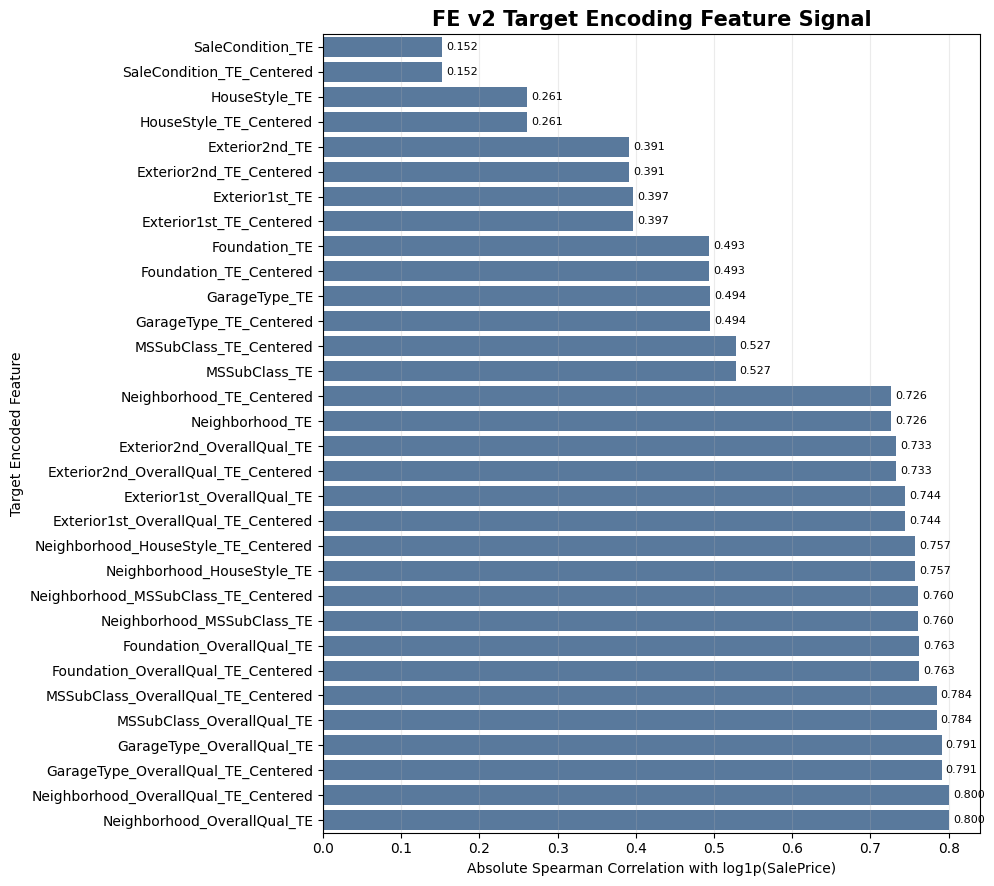

In [16]:
# ============================================================
# 2.9 Plot TE feature signal
# ============================================================

plot_df = te_signal_report.dropna(subset=["abs_spearman_corr"]).copy()

if plot_df.empty:
    print("No TE signal report available.")
else:
    plt.figure(figsize=(10, max(6, len(plot_df) * 0.28)))

    ax = sns.barplot(
        data=plot_df.sort_values("abs_spearman_corr", ascending=True),
        x="abs_spearman_corr",
        y="feature",
        color="#4E79A7"
    )

    plt.title("FE v2 Target Encoding Feature Signal", fontsize=15, fontweight="bold")
    plt.xlabel("Absolute Spearman Correlation with log1p(SalePrice)")
    plt.ylabel("Target Encoded Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_V2_DIR / "02_01_target_encoding_feature_signal.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Plot top TE category stat

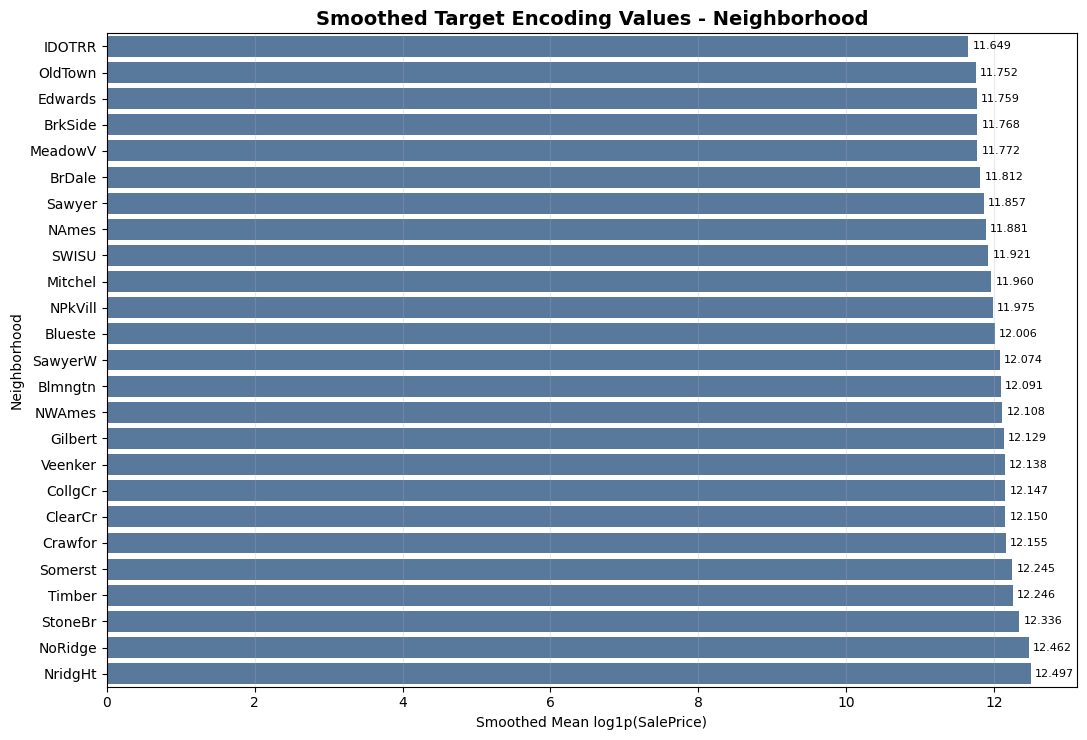

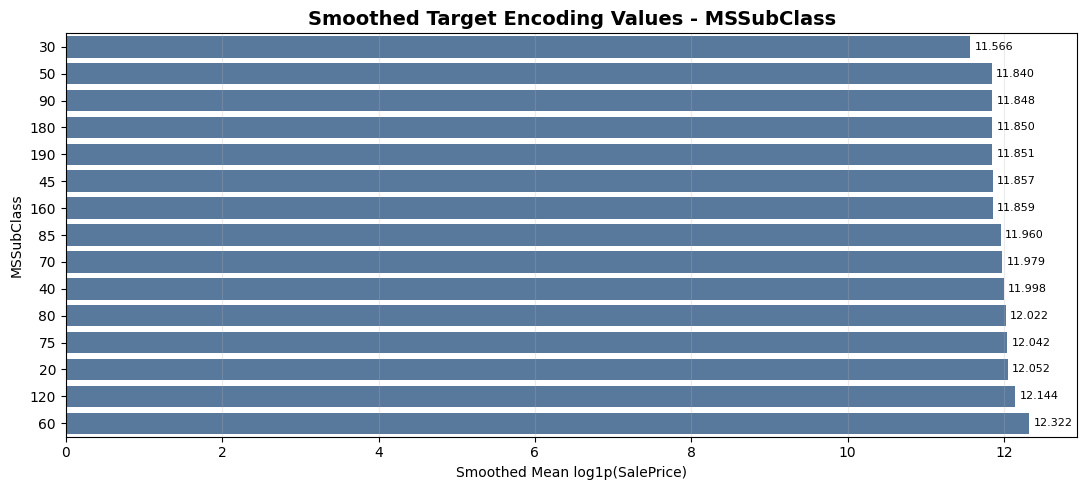

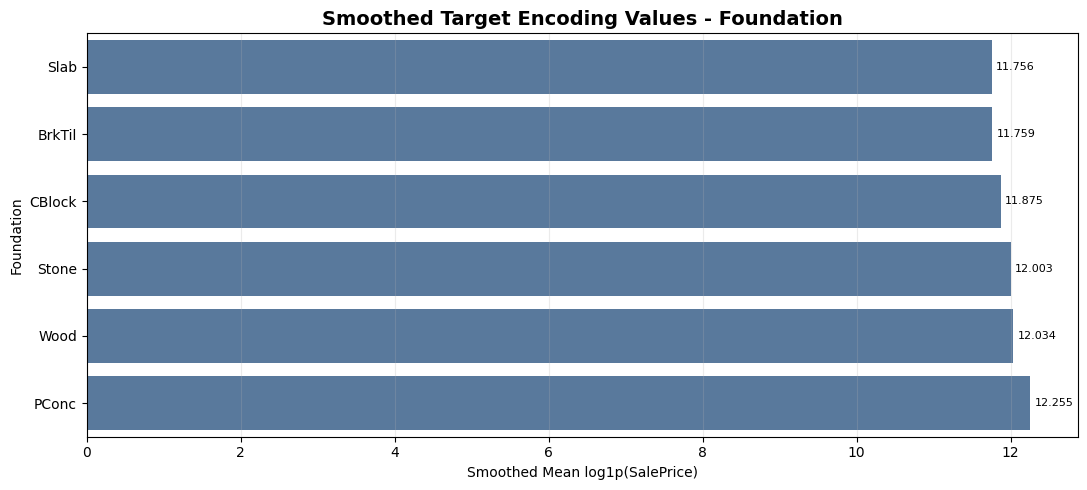

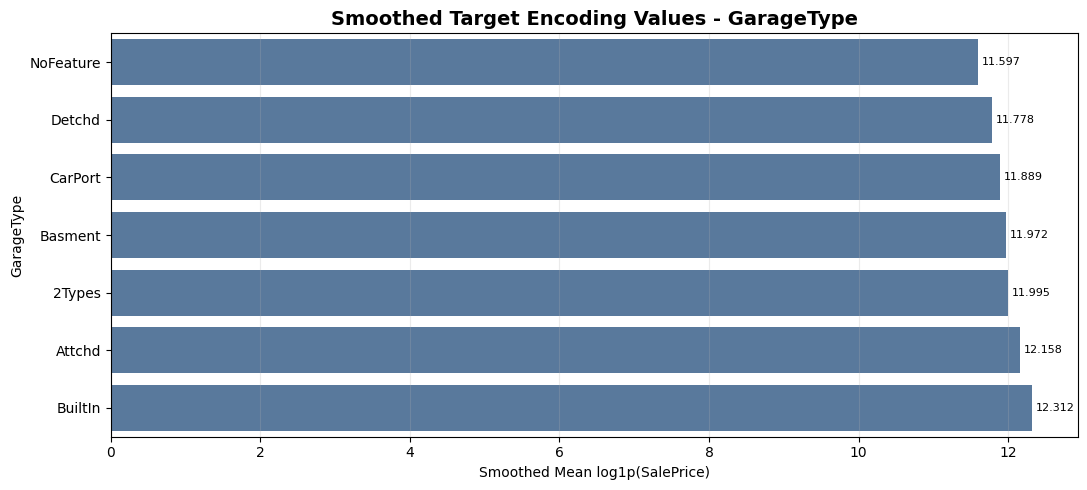

In [17]:
# ============================================================
# 2.10 Plot top TE category stats
# ============================================================

important_te_base_features = [
    "Neighborhood",
    "MSSubClass",
    "Foundation",
    "GarageType"
]

for feature in important_te_base_features:
    stats_df = te_full_stats_all.loc[
        te_full_stats_all["feature"] == feature
    ].copy()

    if stats_df.empty:
        continue

    stats_df = stats_df.sort_values("encoded_value", ascending=False).head(25)

    plt.figure(figsize=(11, max(5, len(stats_df) * 0.30)))

    ax = sns.barplot(
        data=stats_df.sort_values("encoded_value", ascending=True),
        x="encoded_value",
        y="category",
        color="#4E79A7"
    )

    plt.title(f"Smoothed Target Encoding Values - {feature}", fontsize=14, fontweight="bold")
    plt.xlabel("Smoothed Mean log1p(SalePrice)")
    plt.ylabel(feature)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_V2_DIR / f"02_te_category_values_{feature}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### TE missing and alignment check

In [18]:
# ============================================================
# 2.11 TE missing and alignment check
# ============================================================

te_validation_rows = []

for col in te_created_features:
    te_validation_rows.append({
        "feature": col,
        "train_missing": int(X_train_v2_te[col].isna().sum()),
        "test_missing": int(X_test_v2_te[col].isna().sum()),
        "train_min": X_train_v2_te[col].min(),
        "train_max": X_train_v2_te[col].max(),
        "test_min": X_test_v2_te[col].min(),
        "test_max": X_test_v2_te[col].max(),
        "train_unique": X_train_v2_te[col].nunique(dropna=True),
        "test_unique": X_test_v2_te[col].nunique(dropna=True),
    })

te_validation_report = pd.DataFrame(te_validation_rows)

te_validation_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "02_target_encoding_validation_report.csv",
    index=False
)

te_validation_report

,feature,train_missing,test_missing,train_min,train_max,test_min,test_max,train_unique,test_unique
0,Neighborhood_TE,0,0,11.639891,12.496412,11.649397,12.496652,225,25
1,Neighborhood_TE_Centered,0,0,-0.384124,0.472396,-0.374618,0.472637,225,25
2,MSSubClass_TE,0,0,11.560698,12.327600,11.566448,12.321843,136,16
3,MSSubClass_TE_Centered,0,0,-0.463317,0.303585,-0.457567,0.297828,136,16
4,Exterior1st_TE,0,0,11.773143,12.204300,11.774270,12.199079,106,13
5,Exterior1st_TE_Centered,0,0,-0.250872,0.180285,-0.249745,0.175064,106,13
6,Exterior2nd_TE,0,0,11.791855,12.207907,11.797123,12.202551,117,15
7,Exterior2nd_TE_Centered,0,0,-0.232160,0.183892,-0.226892,0.178536,117,15
8,Foundation_TE,0,0,11.745860,12.262493,11.756172,12.255145,46,6
9,Foundation_TE_Centered,0,0,-0.278155,0.238477,-0.267843,0.231129,46,6


### Save TE checkpoint datasets

In [19]:
# ============================================================
# 2.12 Save TE checkpoint datasets
# ============================================================

X_train_v2_te.to_csv(
    FE_RESULT_V2_DIR / "02_X_train_v2_target_encoded_checkpoint.csv",
    index=False
)

X_test_v2_te.to_csv(
    FE_RESULT_V2_DIR / "02_X_test_v2_target_encoded_checkpoint.csv",
    index=False
)

print("Saved TE checkpoint datasets:")
print(FE_RESULT_V2_DIR / "02_X_train_v2_target_encoded_checkpoint.csv")
print(FE_RESULT_V2_DIR / "02_X_test_v2_target_encoded_checkpoint.csv")

Saved TE checkpoint datasets:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\02_X_train_v2_target_encoded_checkpoint.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\02_X_test_v2_target_encoded_checkpoint.csv


### Final TE safety check

In [20]:
# ============================================================
# 2.13 Final TE safety check
# ============================================================

assert X_train_v2_te.shape[0] == len(y_log_v2)
assert X_test_v2_te.shape[0] == len(test_ids_v2)
assert X_train_v2_te.columns.equals(X_test_v2_te.columns)

te_missing_train = X_train_v2_te[te_created_features].isna().sum().sum()
te_missing_test = X_test_v2_te[te_created_features].isna().sum().sum()

if te_missing_train > 0 or te_missing_test > 0:
    raise ValueError(
        f"Missing values found in TE features. Train: {te_missing_train}, Test: {te_missing_test}"
    )

print("Target encoding completed safely.")
print("TE features created:", len(te_created_features))
print("X_train_v2_te:", X_train_v2_te.shape)
print("X_test_v2_te:", X_test_v2_te.shape)

Target encoding completed safely.
TE features created: 32
X_train_v2_te: (1458, 169)
X_test_v2_te: (1459, 169)


### Manual Decision

Leakage-safe OOF target encoding is complete.

Main decisions:

- Target encoding was created using `log1p(SalePrice)`.
- Train target encoding was generated out-of-fold only.
- Test target encoding used full-train smoothed statistics.
- Smoothing was applied to reduce overfitting from rare categories.
- Centered target-encoding versions were also created.
- Single categorical features and selected combined categorical features were encoded.
- Target encoding artifacts and validation reports were saved.

This section directly addresses the main FE v1 weakness:

`Neighborhood` and other high-signal categorical features are now represented as price-aware numeric signals.

Next section:

`3. Neighborhood Price Tier and Location Interaction Features`

## 3. Neighborhood Price Tier and Location Interaction Features

This section creates location-aware interaction features.

Main goal:

- convert neighborhood price signal into price tiers
- combine location signal with quality
- combine location signal with size
- improve low/high price tail prediction

Important:

No model training is done here.

Main feature groups:

- Neighborhood price tier
- Location × quality interactions
- Location × size interactions
- Premium / low-price neighborhood flags

### Create location feature working copies

In [21]:
# ============================================================
# 3.1 Create location feature working copies
# ============================================================

X_train_v2_loc = X_train_v2_te.copy()
X_test_v2_loc = X_test_v2_te.copy()

print("Before location feature creation:")
print("X_train_v2_loc:", X_train_v2_loc.shape)
print("X_test_v2_loc:", X_test_v2_loc.shape)

Before location feature creation:
X_train_v2_loc: (1458, 169)
X_test_v2_loc: (1459, 169)


### Helper functions

In [23]:
# ============================================================
# 3.2 Helper functions
# ============================================================

def get_num_col(df, col, default=0):
    """
    Safely return numeric column.
    Missing columns are returned as default-valued Series.
    """
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(default)
    return pd.Series(default, index=df.index, dtype=float)


def safe_product(df, col_a, col_b):
    """
    Safely multiply two numeric columns.
    """
    return get_num_col(df, col_a, 0) * get_num_col(df, col_b, 0)


def safe_divide(numerator, denominator, fill_value=0):
    """
    Safely divide two arrays/Series.
    """
    result = numerator / denominator.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan).fillna(fill_value)


def keep_existing_columns(columns, train_df, test_df):
    """
    Keep columns that exist in both train and test.
    """
    return [col for col in columns if col in train_df.columns and col in test_df.columns]


print("Location feature helper functions ready.")

Location feature helper functions ready.


### Create Neighborhood price tier from OOF TE

In [24]:
# ============================================================
# 3.3 Create Neighborhood price tier from OOF target encoding
# ============================================================

if "Neighborhood_TE" not in X_train_v2_loc.columns:
    raise ValueError("Neighborhood_TE not found. Run Section 2 target encoding first.")

# Use train OOF TE distribution to create tier bins.
# This avoids direct target leakage because train Neighborhood_TE is OOF encoded.
tier_labels = [0, 1, 2, 3]
tier_names = {
    0: "low",
    1: "mid",
    2: "high",
    3: "premium"
}

_, tier_bins = pd.qcut(
    X_train_v2_loc["Neighborhood_TE"],
    q=4,
    labels=tier_labels,
    retbins=True,
    duplicates="drop"
)

# Make bins open-ended for test safety
tier_bins[0] = -np.inf
tier_bins[-1] = np.inf

X_train_v2_loc["NeighborhoodPriceTier_Ord"] = pd.cut(
    X_train_v2_loc["Neighborhood_TE"],
    bins=tier_bins,
    labels=False,
    include_lowest=True
).astype(int)

X_test_v2_loc["NeighborhoodPriceTier_Ord"] = pd.cut(
    X_test_v2_loc["Neighborhood_TE"],
    bins=tier_bins,
    labels=False,
    include_lowest=True
).astype(int)

X_train_v2_loc["NeighborhoodPriceTier"] = (
    X_train_v2_loc["NeighborhoodPriceTier_Ord"]
    .map(tier_names)
    .astype(str)
)

X_test_v2_loc["NeighborhoodPriceTier"] = (
    X_test_v2_loc["NeighborhoodPriceTier_Ord"]
    .map(tier_names)
    .astype(str)
)

# Binary flags
X_train_v2_loc["IsPremiumNeighborhood"] = (X_train_v2_loc["NeighborhoodPriceTier_Ord"] == 3).astype(int)
X_test_v2_loc["IsPremiumNeighborhood"] = (X_test_v2_loc["NeighborhoodPriceTier_Ord"] == 3).astype(int)

X_train_v2_loc["IsLowPriceNeighborhood"] = (X_train_v2_loc["NeighborhoodPriceTier_Ord"] == 0).astype(int)
X_test_v2_loc["IsLowPriceNeighborhood"] = (X_test_v2_loc["NeighborhoodPriceTier_Ord"] == 0).astype(int)

neighborhood_tier_bins_report = pd.DataFrame({
    "bin_index": range(len(tier_bins)),
    "bin_edge": tier_bins
})

neighborhood_tier_bins_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "03_neighborhood_price_tier_bins.csv",
    index=False
)

print("Neighborhood price tier features created.")
neighborhood_tier_bins_report

Neighborhood price tier features created.


,bin_index,bin_edge
0,0,-inf
1,1,11.859373
2,2,12.051908
3,3,12.145960
4,4,inf


### Neighborhood tier summary

In [25]:
# ============================================================
# 3.4 Neighborhood tier summary
# ============================================================

neighborhood_tier_summary = (
    pd.DataFrame({
        "Neighborhood": X_train_v2_loc["Neighborhood"].astype(str) if "Neighborhood" in X_train_v2_loc.columns else "Unknown",
        "Neighborhood_TE": X_train_v2_loc["Neighborhood_TE"],
        "NeighborhoodPriceTier_Ord": X_train_v2_loc["NeighborhoodPriceTier_Ord"],
        "NeighborhoodPriceTier": X_train_v2_loc["NeighborhoodPriceTier"],
        LOG_TARGET_COL: y_log_v2
    })
    .groupby(["NeighborhoodPriceTier_Ord", "NeighborhoodPriceTier"])
    .agg(
        row_count=("Neighborhood_TE", "count"),
        mean_neighborhood_te=("Neighborhood_TE", "mean"),
        median_neighborhood_te=("Neighborhood_TE", "median"),
        mean_log_target=(LOG_TARGET_COL, "mean"),
        median_log_target=(LOG_TARGET_COL, "median")
    )
    .reset_index()
)

neighborhood_tier_summary.to_csv(
    FE_STEP_REPORT_V2_DIR / "03_neighborhood_price_tier_summary.csv",
    index=False
)

neighborhood_tier_summary

,NeighborhoodPriceTier_Ord,NeighborhoodPriceTier,row_count,mean_neighborhood_te,median_neighborhood_te,mean_log_target,median_log_target
0,0,low,366,11.765279,11.762008,11.668498,11.686887
1,1,mid,367,11.901731,11.881771,11.873521,11.856522
2,2,high,369,12.119277,12.126085,12.169584,12.154785
3,3,premium,356,12.298736,12.242020,12.393778,12.380021


### Plot Neighborhood price tier

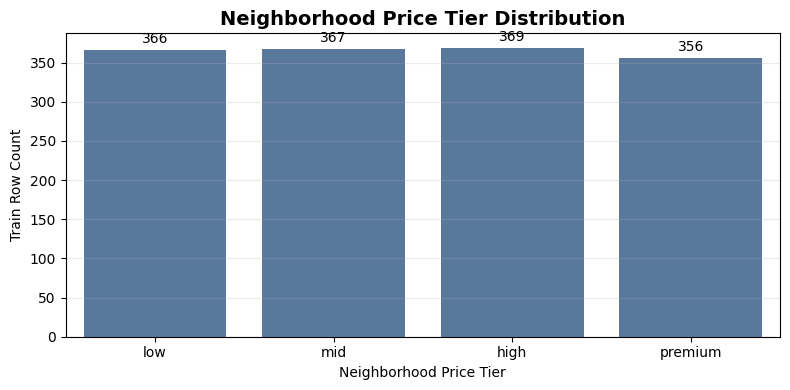

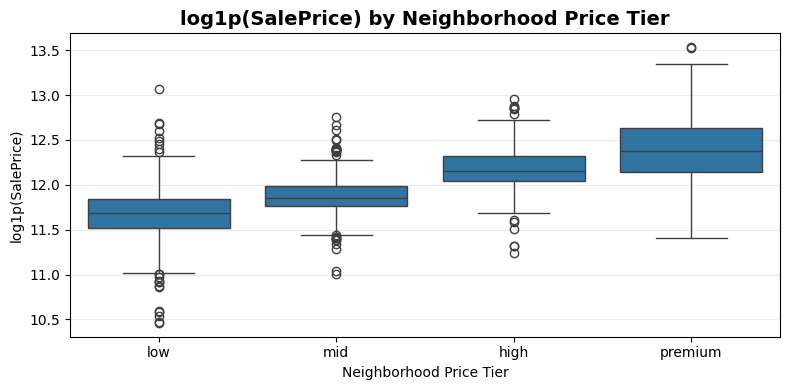

In [26]:
# ============================================================
# 3.5 Plot Neighborhood price tier
# ============================================================

plt.figure(figsize=(8, 4))

ax = sns.countplot(
    data=X_train_v2_loc,
    x="NeighborhoodPriceTier",
    order=["low", "mid", "high", "premium"],
    color="#4E79A7"
)

plt.title("Neighborhood Price Tier Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Neighborhood Price Tier")
plt.ylabel("Train Row Count")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FE_PLOT_V2_DIR / "03_01_neighborhood_price_tier_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(8, 4))

sns.boxplot(
    data=pd.DataFrame({
        "NeighborhoodPriceTier": X_train_v2_loc["NeighborhoodPriceTier"],
        LOG_TARGET_COL: y_log_v2
    }),
    x="NeighborhoodPriceTier",
    y=LOG_TARGET_COL,
    order=["low", "mid", "high", "premium"]
)

plt.title("log1p(SalePrice) by Neighborhood Price Tier", fontsize=14, fontweight="bold")
plt.xlabel("Neighborhood Price Tier")
plt.ylabel("log1p(SalePrice)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FE_PLOT_V2_DIR / "03_02_log_target_by_neighborhood_price_tier.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### Create location × quality interactions

In [27]:
# ============================================================
# 3.6 Create location x quality interactions
# ============================================================

location_quality_base_cols = [
    "OverallQual",
    "OverallCond",
    "ExterQual_Ord",
    "KitchenQual_Ord",
    "BsmtQual_Ord",
    "GarageFinish_Ord",
    "GarageQual_Ord",
    "FireplaceQu_Ord",
]

location_quality_base_cols = keep_existing_columns(
    location_quality_base_cols,
    X_train_v2_loc,
    X_test_v2_loc
)

LOCATION_QUALITY_FEATURES_CREATED = []

for col in location_quality_base_cols:
    new_col = f"{col}_x_Neighborhood_TE"

    X_train_v2_loc[new_col] = get_num_col(X_train_v2_loc, col) * get_num_col(X_train_v2_loc, "Neighborhood_TE")
    X_test_v2_loc[new_col] = get_num_col(X_test_v2_loc, col) * get_num_col(X_test_v2_loc, "Neighborhood_TE")

    LOCATION_QUALITY_FEATURES_CREATED.append(new_col)

    centered_new_col = f"{col}_x_Neighborhood_TE_Centered"

    X_train_v2_loc[centered_new_col] = get_num_col(X_train_v2_loc, col) * get_num_col(X_train_v2_loc, "Neighborhood_TE_Centered")
    X_test_v2_loc[centered_new_col] = get_num_col(X_test_v2_loc, col) * get_num_col(X_test_v2_loc, "Neighborhood_TE_Centered")

    LOCATION_QUALITY_FEATURES_CREATED.append(centered_new_col)

print("Location x quality features created:", len(LOCATION_QUALITY_FEATURES_CREATED))
LOCATION_QUALITY_FEATURES_CREATED

Location x quality features created: 16


['OverallQual_x_Neighborhood_TE',
 'OverallQual_x_Neighborhood_TE_Centered',
 'OverallCond_x_Neighborhood_TE',
 'OverallCond_x_Neighborhood_TE_Centered',
 'ExterQual_Ord_x_Neighborhood_TE',
 'ExterQual_Ord_x_Neighborhood_TE_Centered',
 'KitchenQual_Ord_x_Neighborhood_TE',
 'KitchenQual_Ord_x_Neighborhood_TE_Centered',
 'BsmtQual_Ord_x_Neighborhood_TE',
 'BsmtQual_Ord_x_Neighborhood_TE_Centered',
 'GarageFinish_Ord_x_Neighborhood_TE',
 'GarageFinish_Ord_x_Neighborhood_TE_Centered',
 'GarageQual_Ord_x_Neighborhood_TE',
 'GarageQual_Ord_x_Neighborhood_TE_Centered',
 'FireplaceQu_Ord_x_Neighborhood_TE',
 'FireplaceQu_Ord_x_Neighborhood_TE_Centered']

### Create location × size interactions

In [28]:
# ============================================================
# 3.7 Create location x size interactions
# ============================================================

location_size_base_cols = [
    "GrLivArea",
    "TotalSF",
    "LivingPlusBasementSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "GarageCars",
    "TotalBath",
    "TotalPorchSF",
    "OutdoorSF",
    "LotArea",
    "LotFrontage",
]

location_size_base_cols = keep_existing_columns(
    location_size_base_cols,
    X_train_v2_loc,
    X_test_v2_loc
)

LOCATION_SIZE_FEATURES_CREATED = []

for col in location_size_base_cols:
    new_col = f"Neighborhood_TE_x_{col}"

    X_train_v2_loc[new_col] = get_num_col(X_train_v2_loc, "Neighborhood_TE") * get_num_col(X_train_v2_loc, col)
    X_test_v2_loc[new_col] = get_num_col(X_test_v2_loc, "Neighborhood_TE") * get_num_col(X_test_v2_loc, col)

    LOCATION_SIZE_FEATURES_CREATED.append(new_col)

print("Location x size features created:", len(LOCATION_SIZE_FEATURES_CREATED))
LOCATION_SIZE_FEATURES_CREATED

Location x size features created: 13


['Neighborhood_TE_x_GrLivArea',
 'Neighborhood_TE_x_TotalSF',
 'Neighborhood_TE_x_LivingPlusBasementSF',
 'Neighborhood_TE_x_TotalBsmtSF',
 'Neighborhood_TE_x_1stFlrSF',
 'Neighborhood_TE_x_2ndFlrSF',
 'Neighborhood_TE_x_GarageArea',
 'Neighborhood_TE_x_GarageCars',
 'Neighborhood_TE_x_TotalBath',
 'Neighborhood_TE_x_TotalPorchSF',
 'Neighborhood_TE_x_OutdoorSF',
 'Neighborhood_TE_x_LotArea',
 'Neighborhood_TE_x_LotFrontage']

### Create premium/low neighborhood interaction flags

In [29]:
# ============================================================
# 3.8 Create premium / low neighborhood interaction flags
# ============================================================

# Train-based thresholds for size and quality
total_sf_high_threshold = X_train_v2_loc["TotalSF"].quantile(0.75) if "TotalSF" in X_train_v2_loc.columns else np.nan
grliv_high_threshold = X_train_v2_loc["GrLivArea"].quantile(0.75) if "GrLivArea" in X_train_v2_loc.columns else np.nan
overall_qual_high_threshold = X_train_v2_loc["OverallQual"].quantile(0.75) if "OverallQual" in X_train_v2_loc.columns else np.nan
overall_qual_low_threshold = X_train_v2_loc["OverallQual"].quantile(0.25) if "OverallQual" in X_train_v2_loc.columns else np.nan

for df in [X_train_v2_loc, X_test_v2_loc]:

    df["PremiumNeighborhoodLargeHouse"] = (
        (get_num_col(df, "IsPremiumNeighborhood") == 1) &
        (get_num_col(df, "TotalSF") >= total_sf_high_threshold)
    ).astype(int)

    df["PremiumNeighborhoodHighQuality"] = (
        (get_num_col(df, "IsPremiumNeighborhood") == 1) &
        (get_num_col(df, "OverallQual") >= overall_qual_high_threshold)
    ).astype(int)

    df["LowPriceNeighborhoodLargeHouse"] = (
        (get_num_col(df, "IsLowPriceNeighborhood") == 1) &
        (get_num_col(df, "TotalSF") >= total_sf_high_threshold)
    ).astype(int)

    df["LowPriceNeighborhoodLowQuality"] = (
        (get_num_col(df, "IsLowPriceNeighborhood") == 1) &
        (get_num_col(df, "OverallQual") <= overall_qual_low_threshold)
    ).astype(int)

    df["LargeHighQualityHouse"] = (
        (get_num_col(df, "TotalSF") >= total_sf_high_threshold) &
        (get_num_col(df, "OverallQual") >= overall_qual_high_threshold)
    ).astype(int)

    df["LargeLowQualityHouse"] = (
        (get_num_col(df, "TotalSF") >= total_sf_high_threshold) &
        (get_num_col(df, "OverallQual") <= overall_qual_low_threshold)
    ).astype(int)


LOCATION_FLAG_FEATURES_CREATED = [
    "PremiumNeighborhoodLargeHouse",
    "PremiumNeighborhoodHighQuality",
    "LowPriceNeighborhoodLargeHouse",
    "LowPriceNeighborhoodLowQuality",
    "LargeHighQualityHouse",
    "LargeLowQualityHouse",
]

location_flag_thresholds = pd.DataFrame([
    {"threshold_name": "total_sf_high_75pct", "value": total_sf_high_threshold},
    {"threshold_name": "grliv_high_75pct", "value": grliv_high_threshold},
    {"threshold_name": "overall_qual_high_75pct", "value": overall_qual_high_threshold},
    {"threshold_name": "overall_qual_low_25pct", "value": overall_qual_low_threshold},
])

location_flag_thresholds.to_csv(
    FE_STEP_REPORT_V2_DIR / "03_location_flag_thresholds.csv",
    index=False
)

print("Location flag features created:", len(LOCATION_FLAG_FEATURES_CREATED))
location_flag_thresholds

Location flag features created: 6


,threshold_name,value
0,total_sf_high_75pct,3002.25
1,grliv_high_75pct,1776.00
2,overall_qual_high_75pct,7.00
3,overall_qual_low_25pct,5.00


### Location feature inventory

In [30]:
# ============================================================
# 3.9 Location feature inventory
# ============================================================

LOCATION_TIER_FEATURES_CREATED = [
    "NeighborhoodPriceTier_Ord",
    "NeighborhoodPriceTier",
    "IsPremiumNeighborhood",
    "IsLowPriceNeighborhood",
]

LOCATION_FEATURES_CREATED = (
    LOCATION_TIER_FEATURES_CREATED +
    LOCATION_QUALITY_FEATURES_CREATED +
    LOCATION_SIZE_FEATURES_CREATED +
    LOCATION_FLAG_FEATURES_CREATED
)

location_feature_inventory = pd.DataFrame([
    {
        "feature": col,
        "train_dtype": str(X_train_v2_loc[col].dtype),
        "test_dtype": str(X_test_v2_loc[col].dtype),
        "train_missing": int(X_train_v2_loc[col].isna().sum()),
        "test_missing": int(X_test_v2_loc[col].isna().sum()),
        "train_unique": int(X_train_v2_loc[col].nunique(dropna=True)),
        "test_unique": int(X_test_v2_loc[col].nunique(dropna=True)),
    }
    for col in LOCATION_FEATURES_CREATED
    if col in X_train_v2_loc.columns and col in X_test_v2_loc.columns
])

location_feature_inventory.to_csv(
    FE_STEP_REPORT_V2_DIR / "03_location_feature_inventory.csv",
    index=False
)

location_feature_inventory

,feature,train_dtype,test_dtype,train_missing,test_missing,train_unique,test_unique
0,NeighborhoodPriceTier_Ord,int64,int64,0,0,4,4
1,NeighborhoodPriceTier,object,object,0,0,4,4
2,IsPremiumNeighborhood,int64,int64,0,0,2,2
3,IsLowPriceNeighborhood,int64,int64,0,0,2,2
4,OverallQual_x_Neighborhood_TE,float64,float64,0,0,612,113
5,OverallQual_x_Neighborhood_TE_Centered,float64,float64,0,0,612,113
6,OverallCond_x_Neighborhood_TE,float64,float64,0,0,540,121
7,OverallCond_x_Neighborhood_TE_Centered,float64,float64,0,0,540,121
8,ExterQual_Ord_x_Neighborhood_TE,float64,float64,0,0,356,59
9,ExterQual_Ord_x_Neighborhood_TE_Centered,float64,float64,0,0,356,59


###  Location feature family summary

In [31]:
# ============================================================
# 3.10 Location feature family summary
# ============================================================

location_family_summary = pd.DataFrame([
    {
        "feature_family": "neighborhood_price_tier",
        "feature_count": len([c for c in LOCATION_TIER_FEATURES_CREATED if c in X_train_v2_loc.columns]),
        "features": ", ".join([c for c in LOCATION_TIER_FEATURES_CREATED if c in X_train_v2_loc.columns])
    },
    {
        "feature_family": "location_quality_interaction",
        "feature_count": len(LOCATION_QUALITY_FEATURES_CREATED),
        "features": ", ".join(LOCATION_QUALITY_FEATURES_CREATED)
    },
    {
        "feature_family": "location_size_interaction",
        "feature_count": len(LOCATION_SIZE_FEATURES_CREATED),
        "features": ", ".join(LOCATION_SIZE_FEATURES_CREATED)
    },
    {
        "feature_family": "location_tail_flags",
        "feature_count": len(LOCATION_FLAG_FEATURES_CREATED),
        "features": ", ".join(LOCATION_FLAG_FEATURES_CREATED)
    },
])

location_family_summary.to_csv(
    FE_STEP_REPORT_V2_DIR / "03_location_feature_family_summary.csv",
    index=False
)

location_family_summary

,feature_family,feature_count,features
0,neighborhood_price_tier,4,"NeighborhoodPriceTier_Ord, NeighborhoodPriceTi..."
1,location_quality_interaction,16,"OverallQual_x_Neighborhood_TE, OverallQual_x_N..."
2,location_size_interaction,13,"Neighborhood_TE_x_GrLivArea, Neighborhood_TE_x..."
3,location_tail_flags,6,"PremiumNeighborhoodLargeHouse, PremiumNeighbor..."


### Plot location feature family summary

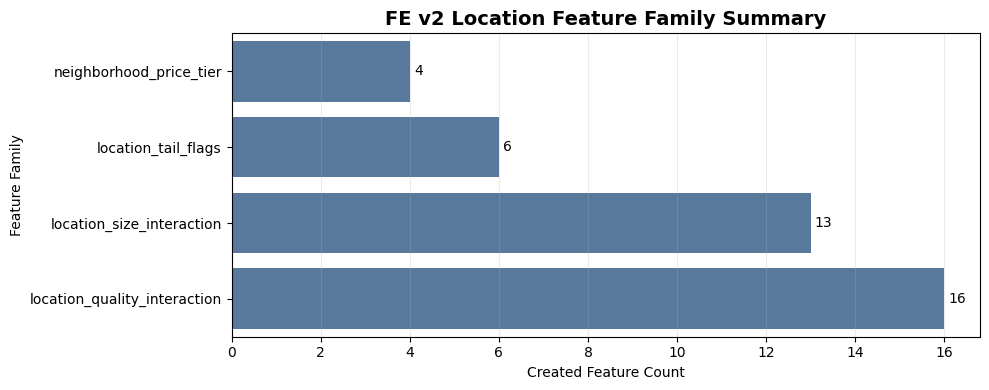

In [32]:
# ============================================================
# 3.11 Plot location feature family summary
# ============================================================

plot_df = location_family_summary.sort_values("feature_count", ascending=True)

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=plot_df,
    x="feature_count",
    y="feature_family",
    color="#4E79A7"
)

plt.title("FE v2 Location Feature Family Summary", fontsize=14, fontweight="bold")
plt.xlabel("Created Feature Count")
plt.ylabel("Feature Family")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FE_PLOT_V2_DIR / "03_03_location_feature_family_summary.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### Location feature signal report

In [33]:
# ============================================================
# 3.12 Location feature signal report
# ============================================================

location_signal_rows = []

for col in LOCATION_FEATURES_CREATED:
    if col not in X_train_v2_loc.columns:
        continue

    if not pd.api.types.is_numeric_dtype(X_train_v2_loc[col]):
        continue

    pearson_corr = X_train_v2_loc[col].corr(y_log_v2, method="pearson")
    spearman_corr = X_train_v2_loc[col].corr(y_log_v2, method="spearman")

    location_signal_rows.append({
        "feature": col,
        "pearson_corr_with_log_target": pearson_corr,
        "spearman_corr_with_log_target": spearman_corr,
        "abs_spearman_corr": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan
    })

location_feature_signal_report = pd.DataFrame(location_signal_rows).sort_values(
    "abs_spearman_corr",
    ascending=False
).reset_index(drop=True)

location_feature_signal_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "03_location_feature_signal_report.csv",
    index=False
)

location_feature_signal_report.head(30)

,feature,pearson_corr_with_log_target,spearman_corr_with_log_target,abs_spearman_corr
0,OverallQual_x_Neighborhood_TE,0.833174,0.843886,0.843886
1,Neighborhood_TE_x_TotalSF,0.840395,0.837809,0.837809
2,Neighborhood_TE_x_LivingPlusBasementSF,0.836371,0.833397,0.833397
3,Neighborhood_TE_x_GarageCars,0.698028,0.788172,0.788172
4,KitchenQual_Ord_x_Neighborhood_TE,0.700435,0.776495,0.776495
5,ExterQual_Ord_x_Neighborhood_TE,0.708003,0.775848,0.775848
6,Neighborhood_TE_x_TotalBath,0.695953,0.773159,0.773159
7,BsmtQual_Ord_x_Neighborhood_TE,0.644630,0.759804,0.759804
8,Neighborhood_TE_x_GrLivArea,0.746897,0.754454,0.754454
9,GarageQual_Ord_x_Neighborhood_TE,0.408928,0.742028,0.742028


### Plot top location feature signal

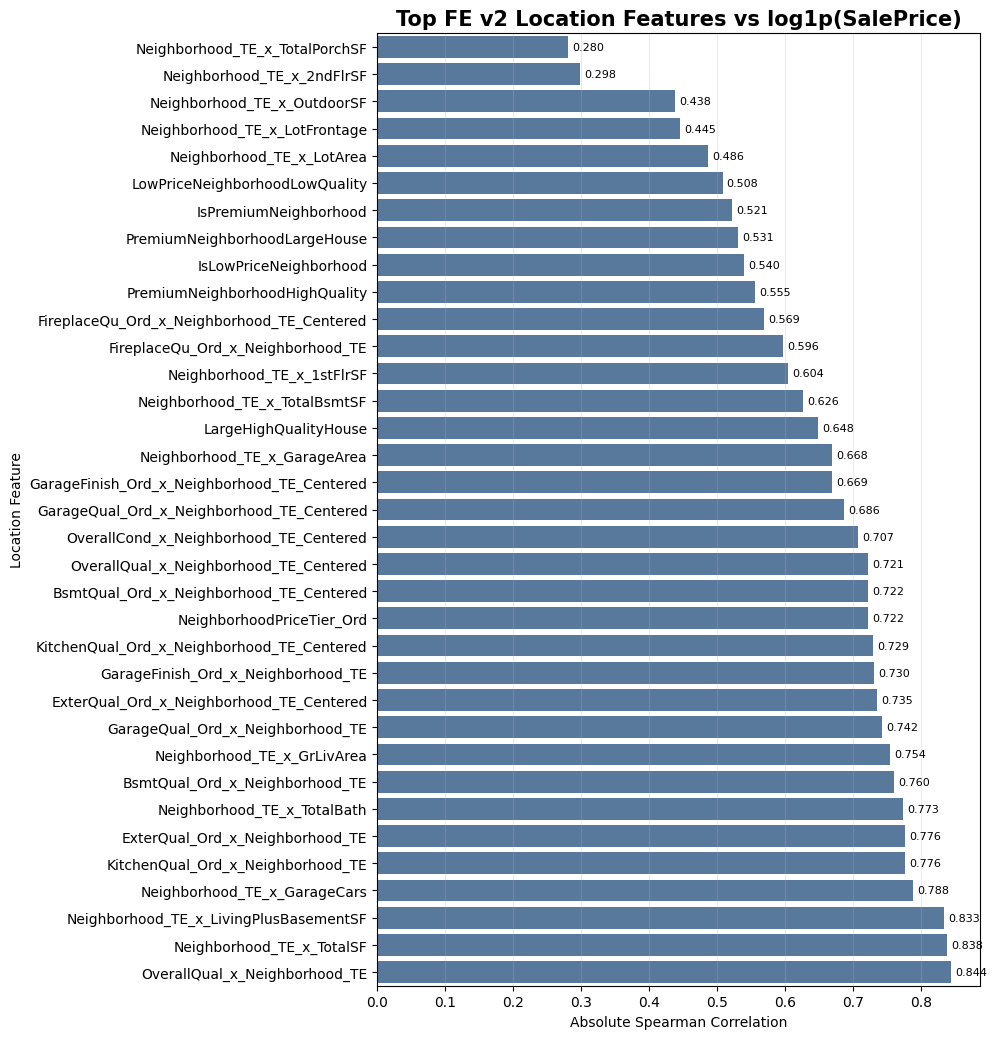

In [34]:
# ============================================================
# 3.13 Plot top location feature signal
# ============================================================

plot_df = location_feature_signal_report.dropna(subset=["abs_spearman_corr"]).head(35).copy()

if plot_df.empty:
    print("No numeric location feature signal to plot.")
else:
    plt.figure(figsize=(10, max(6, len(plot_df) * 0.30)))

    ax = sns.barplot(
        data=plot_df.sort_values("abs_spearman_corr", ascending=True),
        x="abs_spearman_corr",
        y="feature",
        color="#4E79A7"
    )

    plt.title("Top FE v2 Location Features vs log1p(SalePrice)", fontsize=15, fontweight="bold")
    plt.xlabel("Absolute Spearman Correlation")
    plt.ylabel("Location Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_V2_DIR / "03_04_top_location_feature_signal.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Location feature missing check

In [35]:
# ============================================================
# 3.14 Location feature missing check
# ============================================================

location_missing_report = pd.DataFrame([
    {
        "feature": col,
        "train_missing": int(X_train_v2_loc[col].isna().sum()),
        "test_missing": int(X_test_v2_loc[col].isna().sum()),
        "train_missing_pct": round(X_train_v2_loc[col].isna().mean() * 100, 3),
        "test_missing_pct": round(X_test_v2_loc[col].isna().mean() * 100, 3),
    }
    for col in LOCATION_FEATURES_CREATED
    if col in X_train_v2_loc.columns and col in X_test_v2_loc.columns
])

location_missing_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "03_location_feature_missing_report.csv",
    index=False
)

location_missing_report

,feature,train_missing,test_missing,train_missing_pct,test_missing_pct
0,NeighborhoodPriceTier_Ord,0,0,0.0,0.0
1,NeighborhoodPriceTier,0,0,0.0,0.0
2,IsPremiumNeighborhood,0,0,0.0,0.0
3,IsLowPriceNeighborhood,0,0,0.0,0.0
4,OverallQual_x_Neighborhood_TE,0,0,0.0,0.0
5,OverallQual_x_Neighborhood_TE_Centered,0,0,0.0,0.0
6,OverallCond_x_Neighborhood_TE,0,0,0.0,0.0
7,OverallCond_x_Neighborhood_TE_Centered,0,0,0.0,0.0
8,ExterQual_Ord_x_Neighborhood_TE,0,0,0.0,0.0
9,ExterQual_Ord_x_Neighborhood_TE_Centered,0,0,0.0,0.0


### Save location checkpoint datasets

In [36]:
# ============================================================
# 3.15 Save location checkpoint datasets
# ============================================================

X_train_v2_loc.to_csv(
    FE_RESULT_V2_DIR / "03_X_train_v2_location_features_checkpoint.csv",
    index=False
)

X_test_v2_loc.to_csv(
    FE_RESULT_V2_DIR / "03_X_test_v2_location_features_checkpoint.csv",
    index=False
)

print("Saved location feature checkpoint datasets:")
print(FE_RESULT_V2_DIR / "03_X_train_v2_location_features_checkpoint.csv")
print(FE_RESULT_V2_DIR / "03_X_test_v2_location_features_checkpoint.csv")

Saved location feature checkpoint datasets:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\03_X_train_v2_location_features_checkpoint.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\03_X_test_v2_location_features_checkpoint.csv


### Final location feature safety check

In [37]:
# ============================================================
# 3.16 Final location feature safety check
# ============================================================

assert X_train_v2_loc.shape[0] == len(y_log_v2)
assert X_test_v2_loc.shape[0] == len(test_ids_v2)
assert X_train_v2_loc.columns.equals(X_test_v2_loc.columns)

numeric_location_features = [
    col for col in LOCATION_FEATURES_CREATED
    if col in X_train_v2_loc.columns
    and pd.api.types.is_numeric_dtype(X_train_v2_loc[col])
]

train_missing_total = int(X_train_v2_loc[numeric_location_features].isna().sum().sum())
test_missing_total = int(X_test_v2_loc[numeric_location_features].isna().sum().sum())

train_inf_total = int(np.isinf(X_train_v2_loc[numeric_location_features]).sum().sum())
test_inf_total = int(np.isinf(X_test_v2_loc[numeric_location_features]).sum().sum())

if train_missing_total > 0 or test_missing_total > 0:
    raise ValueError(f"Missing values found in location numeric features. Train={train_missing_total}, Test={test_missing_total}")

if train_inf_total > 0 or test_inf_total > 0:
    raise ValueError(f"Infinite values found in location numeric features. Train={train_inf_total}, Test={test_inf_total}")

print("Location feature creation completed safely.")
print("Created location features:", len(LOCATION_FEATURES_CREATED))
print("X_train_v2_loc:", X_train_v2_loc.shape)
print("X_test_v2_loc:", X_test_v2_loc.shape)

Location feature creation completed safely.
Created location features: 39
X_train_v2_loc: (1458, 208)
X_test_v2_loc: (1459, 208)


### Manual Decision

Neighborhood price tier and location interaction features have been created.

Main decisions:

- `Neighborhood_TE` was converted into `NeighborhoodPriceTier`.
- Premium and low-price neighborhood flags were created.
- Location × quality interactions were created.
- Location × size interactions were created.
- Tail-oriented flags were created for premium/low-price large houses.
- These features directly target the main FE v1 weakness: shallow location representation.

Expected benefit:

- better public generalization
- better handling of high-price houses
- better handling of low-price / large but low-location-value houses
- stronger linear/kernel model signal

Next section:

`4. Quality-Age, Garage, Basement, and Tail-Risk Features`

## 4. Quality-Age, Garage, Basement, and Tail-Risk Features

This section creates higher-level features for:

- quality × age/remodel interaction
- garage score refinement
- basement score refinement
- bath/room ratio features
- luxury score
- low-quality risk score
- tail-specific flags

Main goal:

Improve low-price and high-price tail prediction.

### Create working copies

In [38]:
# ============================================================
# 4.1 Create quality/garage/basement working copies
# ============================================================

X_train_v2_qgb = X_train_v2_loc.copy()
X_test_v2_qgb = X_test_v2_loc.copy()

print("Before Section 4 feature creation:")
print("X_train_v2_qgb:", X_train_v2_qgb.shape)
print("X_test_v2_qgb:", X_test_v2_qgb.shape)

Before Section 4 feature creation:
X_train_v2_qgb: (1458, 208)
X_test_v2_qgb: (1459, 208)


### Additional helper functions

In [39]:
# ============================================================
# 4.2 Additional helper functions
# ============================================================

def get_positive_num_col(df, col, default=0):
    """
    Return numeric column clipped at 0.
    Useful for ordinal score features where NoFeature may be -1.
    """
    return get_num_col(df, col, default).clip(lower=0)


def safe_binary_condition(condition):
    """
    Convert boolean condition to int.
    """
    return condition.astype(int)


print("Section 4 helper functions ready.")

Section 4 helper functions ready.


### Quality × age/remodel features

In [40]:
# ============================================================
# 4.3 Quality x age/remodel features
# ============================================================

QUALITY_AGE_FEATURES_CREATED = []

# Train-based thresholds
house_age_high_threshold = X_train_v2_qgb["HouseAge"].quantile(0.75) if "HouseAge" in X_train_v2_qgb.columns else 50
house_age_very_high_threshold = X_train_v2_qgb["HouseAge"].quantile(0.90) if "HouseAge" in X_train_v2_qgb.columns else 80
remod_age_high_threshold = X_train_v2_qgb["RemodAge"].quantile(0.75) if "RemodAge" in X_train_v2_qgb.columns else 40
overall_qual_high_threshold = X_train_v2_qgb["OverallQual"].quantile(0.75) if "OverallQual" in X_train_v2_qgb.columns else 7
overall_qual_low_threshold = X_train_v2_qgb["OverallQual"].quantile(0.25) if "OverallQual" in X_train_v2_qgb.columns else 5

for df in [X_train_v2_qgb, X_test_v2_qgb]:

    df["OverallQual_x_HouseAge"] = get_num_col(df, "OverallQual") * get_num_col(df, "HouseAge")
    df["OverallQual_x_RemodAge"] = get_num_col(df, "OverallQual") * get_num_col(df, "RemodAge")

    df["Neighborhood_TE_x_HouseAge"] = get_num_col(df, "Neighborhood_TE") * get_num_col(df, "HouseAge")
    df["Neighborhood_TE_x_RemodAge"] = get_num_col(df, "Neighborhood_TE") * get_num_col(df, "RemodAge")

    df["QualityAgeIndex"] = get_num_col(df, "OverallQual") / (get_num_col(df, "HouseAge") + 1)
    df["QualityRemodIndex"] = get_num_col(df, "OverallQual") / (get_num_col(df, "RemodAge") + 1)
    df["AgePenaltyByQuality"] = get_num_col(df, "HouseAge") / (get_num_col(df, "OverallQual") + 1)

    df["IsVeryOldHouse"] = safe_binary_condition(
        get_num_col(df, "HouseAge") >= house_age_very_high_threshold
    )

    df["IsOldButRemodeled"] = safe_binary_condition(
        (get_num_col(df, "HouseAge") >= house_age_high_threshold) &
        (get_num_col(df, "RemodAge") <= remod_age_high_threshold)
    )

    df["OldLowQualityHouse"] = safe_binary_condition(
        (get_num_col(df, "HouseAge") >= house_age_high_threshold) &
        (get_num_col(df, "OverallQual") <= overall_qual_low_threshold)
    )

    df["NewHighQualityHouse"] = safe_binary_condition(
        (get_num_col(df, "HouseAge") <= 5) &
        (get_num_col(df, "OverallQual") >= overall_qual_high_threshold)
    )

QUALITY_AGE_FEATURES_CREATED = [
    "OverallQual_x_HouseAge",
    "OverallQual_x_RemodAge",
    "Neighborhood_TE_x_HouseAge",
    "Neighborhood_TE_x_RemodAge",
    "QualityAgeIndex",
    "QualityRemodIndex",
    "AgePenaltyByQuality",
    "IsVeryOldHouse",
    "IsOldButRemodeled",
    "OldLowQualityHouse",
    "NewHighQualityHouse",
]

quality_age_threshold_report = pd.DataFrame([
    {"threshold": "house_age_high_75pct", "value": house_age_high_threshold},
    {"threshold": "house_age_very_high_90pct", "value": house_age_very_high_threshold},
    {"threshold": "remod_age_high_75pct", "value": remod_age_high_threshold},
    {"threshold": "overall_qual_high_75pct", "value": overall_qual_high_threshold},
    {"threshold": "overall_qual_low_25pct", "value": overall_qual_low_threshold},
])

quality_age_threshold_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "04_quality_age_threshold_report.csv",
    index=False
)

print("Quality-age features created:", len(QUALITY_AGE_FEATURES_CREATED))
quality_age_threshold_report

Quality-age features created: 11


,threshold,value
0,house_age_high_75pct,54.0
1,house_age_very_high_90pct,84.0
2,remod_age_high_75pct,41.0
3,overall_qual_high_75pct,7.0
4,overall_qual_low_25pct,5.0


### Garage refinement features

In [41]:
# ============================================================
# 4.4 Garage refinement features
# ============================================================

GARAGE_REFINED_FEATURES_CREATED = []

garage_area_high_threshold = X_train_v2_qgb["GarageArea"].quantile(0.75) if "GarageArea" in X_train_v2_qgb.columns else 500

for df in [X_train_v2_qgb, X_test_v2_qgb]:

    df["GarageScore"] = get_num_col(df, "GarageCars") * get_num_col(df, "GarageArea")

    df["GarageAreaPerCar"] = safe_divide(
        get_num_col(df, "GarageArea"),
        get_num_col(df, "GarageCars") + 1
    )

    df["GarageQualityAreaScore"] = (
        get_positive_num_col(df, "GarageQual_Ord") *
        get_num_col(df, "GarageArea")
    )

    df["GarageFinishAreaScore"] = (
        get_positive_num_col(df, "GarageFinish_Ord") *
        get_num_col(df, "GarageArea")
    )

    df["OverallQual_x_GarageScore"] = (
        get_num_col(df, "OverallQual") *
        get_num_col(df, "GarageScore")
    )

    df["Neighborhood_TE_x_GarageScore"] = (
        get_num_col(df, "Neighborhood_TE") *
        get_num_col(df, "GarageScore")
    )

    df["HasLargeGarage"] = safe_binary_condition(
        get_num_col(df, "GarageArea") >= garage_area_high_threshold
    )

    df["LargeHighQualityGarage"] = safe_binary_condition(
        (get_num_col(df, "GarageArea") >= garage_area_high_threshold) &
        (get_positive_num_col(df, "GarageQual_Ord") >= 3)
    )

GARAGE_REFINED_FEATURES_CREATED = [
    "GarageScore",
    "GarageAreaPerCar",
    "GarageQualityAreaScore",
    "GarageFinishAreaScore",
    "OverallQual_x_GarageScore",
    "Neighborhood_TE_x_GarageScore",
    "HasLargeGarage",
    "LargeHighQualityGarage",
]

garage_threshold_report = pd.DataFrame([
    {"threshold": "garage_area_high_75pct", "value": garage_area_high_threshold}
])

garage_threshold_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "04_garage_threshold_report.csv",
    index=False
)

print("Garage refined features created:", len(GARAGE_REFINED_FEATURES_CREATED))
garage_threshold_report

Garage refined features created: 8


,threshold,value
0,garage_area_high_75pct,576.0


### Basement refinement features

In [42]:
# ============================================================
# 4.5 Basement refinement features
# ============================================================

BASEMENT_REFINED_FEATURES_CREATED = []

for df in [X_train_v2_qgb, X_test_v2_qgb]:

    df["BasementScore"] = (
        get_num_col(df, "TotalBsmtSF") *
        get_positive_num_col(df, "BsmtQual_Ord")
    )

    df["BasementQualityAreaScore"] = (
        get_num_col(df, "TotalBsmtSF") *
        get_positive_num_col(df, "BsmtQual_Ord")
    )

    df["BasementExposureAreaScore"] = (
        get_num_col(df, "TotalBsmtSF") *
        get_positive_num_col(df, "BsmtExposure_Ord")
    )

    df["FinishedBasementSF"] = (
        get_num_col(df, "BsmtFinSF1") +
        get_num_col(df, "BsmtFinSF2")
    )

    df["FinishedBasementRatio"] = safe_divide(
        get_num_col(df, "FinishedBasementSF"),
        get_num_col(df, "TotalBsmtSF") + 1
    )

    df["UnfinishedBasementRatio"] = safe_divide(
        get_num_col(df, "BsmtUnfSF"),
        get_num_col(df, "TotalBsmtSF") + 1
    )

    df["OverallQual_x_BasementQualityAreaScore"] = (
        get_num_col(df, "OverallQual") *
        get_num_col(df, "BasementQualityAreaScore")
    )

    df["Neighborhood_TE_x_BasementQualityAreaScore"] = (
        get_num_col(df, "Neighborhood_TE") *
        get_num_col(df, "BasementQualityAreaScore")
    )

BASEMENT_REFINED_FEATURES_CREATED = [
    "BasementScore",
    "BasementQualityAreaScore",
    "BasementExposureAreaScore",
    "FinishedBasementSF",
    "FinishedBasementRatio",
    "UnfinishedBasementRatio",
    "OverallQual_x_BasementQualityAreaScore",
    "Neighborhood_TE_x_BasementQualityAreaScore",
]

print("Basement refined features created:", len(BASEMENT_REFINED_FEATURES_CREATED))
BASEMENT_REFINED_FEATURES_CREATED

Basement refined features created: 8


['BasementScore',
 'BasementQualityAreaScore',
 'BasementExposureAreaScore',
 'FinishedBasementSF',
 'FinishedBasementRatio',
 'UnfinishedBasementRatio',
 'OverallQual_x_BasementQualityAreaScore',
 'Neighborhood_TE_x_BasementQualityAreaScore']

### Bath and room ratio features

In [43]:
# ============================================================
# 4.6 Bath and room ratio features
# ============================================================

ROOM_RATIO_FEATURES_CREATED = []

for df in [X_train_v2_qgb, X_test_v2_qgb]:

    df["BathPerRoom"] = safe_divide(
        get_num_col(df, "TotalBath"),
        get_num_col(df, "TotRmsAbvGrd") + 1
    )

    df["BathPerBedroom"] = safe_divide(
        get_num_col(df, "TotalBath"),
        get_num_col(df, "BedroomAbvGr") + 1
    )

    df["BedroomPerRoom"] = safe_divide(
        get_num_col(df, "BedroomAbvGr"),
        get_num_col(df, "TotRmsAbvGrd") + 1
    )

    df["RoomSizeAvg"] = safe_divide(
        get_num_col(df, "GrLivArea"),
        get_num_col(df, "TotRmsAbvGrd") + 1
    )

    df["OverallQual_x_RoomSizeAvg"] = (
        get_num_col(df, "OverallQual") *
        get_num_col(df, "RoomSizeAvg")
    )

ROOM_RATIO_FEATURES_CREATED = [
    "BathPerRoom",
    "BathPerBedroom",
    "BedroomPerRoom",
    "RoomSizeAvg",
    "OverallQual_x_RoomSizeAvg",
]

print("Bath/room ratio features created:", len(ROOM_RATIO_FEATURES_CREATED))
ROOM_RATIO_FEATURES_CREATED

Bath/room ratio features created: 5


['BathPerRoom',
 'BathPerBedroom',
 'BedroomPerRoom',
 'RoomSizeAvg',
 'OverallQual_x_RoomSizeAvg']

### Luxury and risk score features

In [44]:
# ============================================================
# 4.7 Luxury and risk score features
# ============================================================

TAIL_RISK_FEATURES_CREATED = []

# Train-based thresholds
total_sf_high_threshold = X_train_v2_qgb["TotalSF"].quantile(0.75) if "TotalSF" in X_train_v2_qgb.columns else 2500
total_sf_low_threshold = X_train_v2_qgb["TotalSF"].quantile(0.25) if "TotalSF" in X_train_v2_qgb.columns else 1200

for df in [X_train_v2_qgb, X_test_v2_qgb]:

    df["LuxuryScore"] = (
        get_num_col(df, "OverallQual") +
        get_positive_num_col(df, "ExterQual_Ord") +
        get_positive_num_col(df, "KitchenQual_Ord") +
        get_positive_num_col(df, "BsmtQual_Ord") +
        get_positive_num_col(df, "GarageFinish_Ord") +
        get_positive_num_col(df, "FireplaceQu_Ord")
    )

    df["LuxuryAreaScore"] = (
        get_num_col(df, "LuxuryScore") *
        np.log1p(get_num_col(df, "TotalSF"))
    )

    df["LuxuryNeighborhoodScore"] = (
        get_num_col(df, "LuxuryScore") *
        get_num_col(df, "Neighborhood_TE")
    )

    df["LowQualityRiskScore"] = (
        (get_num_col(df, "OverallQual") <= overall_qual_low_threshold).astype(int) +
        (get_num_col(df, "HouseAge") >= house_age_high_threshold).astype(int) +
        (get_positive_num_col(df, "ExterQual_Ord") <= 2).astype(int) +
        (get_positive_num_col(df, "KitchenQual_Ord") <= 2).astype(int) +
        (get_num_col(df, "HasGarage") == 0).astype(int) +
        (get_num_col(df, "HasBasement") == 0).astype(int)
    )

    df["PremiumLargeLuxuryHouse"] = safe_binary_condition(
        (get_num_col(df, "IsPremiumNeighborhood") == 1) &
        (get_num_col(df, "TotalSF") >= total_sf_high_threshold) &
        (get_num_col(df, "LuxuryScore") >= df["LuxuryScore"].quantile(0.75))
    )

    df["LowTierSmallLowQualityHouse"] = safe_binary_condition(
        (get_num_col(df, "IsLowPriceNeighborhood") == 1) &
        (get_num_col(df, "TotalSF") <= total_sf_low_threshold) &
        (get_num_col(df, "LowQualityRiskScore") >= 3)
    )

    df["LargeButLowQualityRisk"] = safe_binary_condition(
        (get_num_col(df, "TotalSF") >= total_sf_high_threshold) &
        (get_num_col(df, "OverallQual") <= overall_qual_low_threshold)
    )

TAIL_RISK_FEATURES_CREATED = [
    "LuxuryScore",
    "LuxuryAreaScore",
    "LuxuryNeighborhoodScore",
    "LowQualityRiskScore",
    "PremiumLargeLuxuryHouse",
    "LowTierSmallLowQualityHouse",
    "LargeButLowQualityRisk",
]

tail_threshold_report = pd.DataFrame([
    {"threshold": "total_sf_high_75pct", "value": total_sf_high_threshold},
    {"threshold": "total_sf_low_25pct", "value": total_sf_low_threshold},
])

tail_threshold_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "04_tail_risk_threshold_report.csv",
    index=False
)

print("Tail/luxury/risk features created:", len(TAIL_RISK_FEATURES_CREATED))
tail_threshold_report

Tail/luxury/risk features created: 7


,threshold,value
0,total_sf_high_75pct,3002.25
1,total_sf_low_25pct,2008.50


### Section 4 feature inventory

In [45]:
# ============================================================
# 4.8 Section 4 feature inventory
# ============================================================

SECTION4_FEATURES_CREATED = (
    QUALITY_AGE_FEATURES_CREATED +
    GARAGE_REFINED_FEATURES_CREATED +
    BASEMENT_REFINED_FEATURES_CREATED +
    ROOM_RATIO_FEATURES_CREATED +
    TAIL_RISK_FEATURES_CREATED
)

section4_feature_inventory = pd.DataFrame([
    {
        "feature": col,
        "train_dtype": str(X_train_v2_qgb[col].dtype),
        "test_dtype": str(X_test_v2_qgb[col].dtype),
        "train_missing": int(X_train_v2_qgb[col].isna().sum()),
        "test_missing": int(X_test_v2_qgb[col].isna().sum()),
        "train_unique": int(X_train_v2_qgb[col].nunique(dropna=True)),
        "test_unique": int(X_test_v2_qgb[col].nunique(dropna=True)),
    }
    for col in SECTION4_FEATURES_CREATED
    if col in X_train_v2_qgb.columns and col in X_test_v2_qgb.columns
])

section4_feature_inventory.to_csv(
    FE_STEP_REPORT_V2_DIR / "04_qgb_tail_feature_inventory.csv",
    index=False
)

section4_feature_inventory

,feature,train_dtype,test_dtype,train_missing,test_missing,train_unique,test_unique
0,OverallQual_x_HouseAge,int64,int64,0,0,291,288
1,OverallQual_x_RemodAge,int64,int64,0,0,175,177
2,Neighborhood_TE_x_HouseAge,float64,float64,0,0,1149,544
3,Neighborhood_TE_x_RemodAge,float64,float64,0,0,1100,491
4,QualityAgeIndex,float64,float64,0,0,324,330
5,QualityRemodIndex,float64,float64,0,0,219,213
6,AgePenaltyByQuality,float64,float64,0,0,331,334
7,IsVeryOldHouse,int64,int64,0,0,2,2
8,IsOldButRemodeled,int64,int64,0,0,2,2
9,OldLowQualityHouse,int64,int64,0,0,2,2


### Section 4 feature family summary

In [46]:
# ============================================================
# 4.9 Section 4 feature family summary
# ============================================================

section4_family_summary = pd.DataFrame([
    {
        "feature_family": "quality_age",
        "feature_count": len(QUALITY_AGE_FEATURES_CREATED),
        "features": ", ".join(QUALITY_AGE_FEATURES_CREATED)
    },
    {
        "feature_family": "garage_refined",
        "feature_count": len(GARAGE_REFINED_FEATURES_CREATED),
        "features": ", ".join(GARAGE_REFINED_FEATURES_CREATED)
    },
    {
        "feature_family": "basement_refined",
        "feature_count": len(BASEMENT_REFINED_FEATURES_CREATED),
        "features": ", ".join(BASEMENT_REFINED_FEATURES_CREATED)
    },
    {
        "feature_family": "room_ratio",
        "feature_count": len(ROOM_RATIO_FEATURES_CREATED),
        "features": ", ".join(ROOM_RATIO_FEATURES_CREATED)
    },
    {
        "feature_family": "tail_luxury_risk",
        "feature_count": len(TAIL_RISK_FEATURES_CREATED),
        "features": ", ".join(TAIL_RISK_FEATURES_CREATED)
    },
])

section4_family_summary.to_csv(
    FE_STEP_REPORT_V2_DIR / "04_qgb_tail_feature_family_summary.csv",
    index=False
)

section4_family_summary

,feature_family,feature_count,features
0,quality_age,11,"OverallQual_x_HouseAge, OverallQual_x_RemodAge..."
1,garage_refined,8,"GarageScore, GarageAreaPerCar, GarageQualityAr..."
2,basement_refined,8,"BasementScore, BasementQualityAreaScore, Basem..."
3,room_ratio,5,"BathPerRoom, BathPerBedroom, BedroomPerRoom, R..."
4,tail_luxury_risk,7,"LuxuryScore, LuxuryAreaScore, LuxuryNeighborho..."


### Plot Section 4 family summary

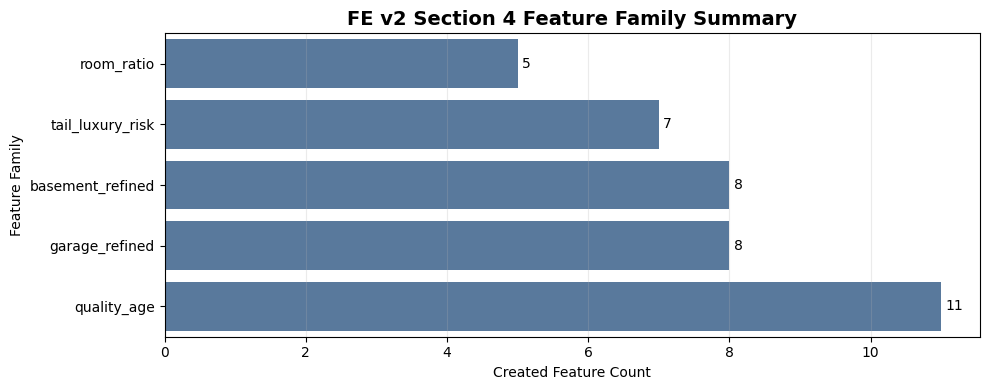

In [47]:
# ============================================================
# 4.10 Plot Section 4 family summary
# ============================================================

plot_df = section4_family_summary.sort_values("feature_count", ascending=True)

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=plot_df,
    x="feature_count",
    y="feature_family",
    color="#4E79A7"
)

plt.title("FE v2 Section 4 Feature Family Summary", fontsize=14, fontweight="bold")
plt.xlabel("Created Feature Count")
plt.ylabel("Feature Family")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FE_PLOT_V2_DIR / "04_01_qgb_tail_feature_family_summary.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### Section 4 feature signal report

In [48]:
# ============================================================
# 4.11 Section 4 feature signal report
# ============================================================

section4_signal_rows = []

for col in SECTION4_FEATURES_CREATED:
    if col not in X_train_v2_qgb.columns:
        continue

    if not pd.api.types.is_numeric_dtype(X_train_v2_qgb[col]):
        continue

    pearson_corr = X_train_v2_qgb[col].corr(y_log_v2, method="pearson")
    spearman_corr = X_train_v2_qgb[col].corr(y_log_v2, method="spearman")

    section4_signal_rows.append({
        "feature": col,
        "pearson_corr_with_log_target": pearson_corr,
        "spearman_corr_with_log_target": spearman_corr,
        "abs_spearman_corr": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan
    })

section4_feature_signal_report = pd.DataFrame(section4_signal_rows).sort_values(
    "abs_spearman_corr",
    ascending=False
).reset_index(drop=True)

section4_feature_signal_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "04_qgb_tail_feature_signal_report.csv",
    index=False
)

section4_feature_signal_report.head(30)

,feature,pearson_corr_with_log_target,spearman_corr_with_log_target,abs_spearman_corr
0,LuxuryAreaScore,0.878261,0.886092,0.886092
1,LuxuryNeighborhoodScore,0.857303,0.869080,0.869080
2,LuxuryScore,0.849886,0.857461,0.857461
3,OverallQual_x_RoomSizeAvg,0.833913,0.843260,0.843260
4,OverallQual_x_BasementQualityAreaScore,0.792226,0.827143,0.827143
5,OverallQual_x_GarageScore,0.759648,0.795623,0.795623
6,GarageFinishAreaScore,0.730943,0.748044,0.748044
7,Neighborhood_TE_x_BasementQualityAreaScore,0.751667,0.740340,0.740340
8,BasementScore,0.744463,0.729132,0.729132
9,BasementQualityAreaScore,0.744463,0.729132,0.729132


### Plot top Section 4 feature signal

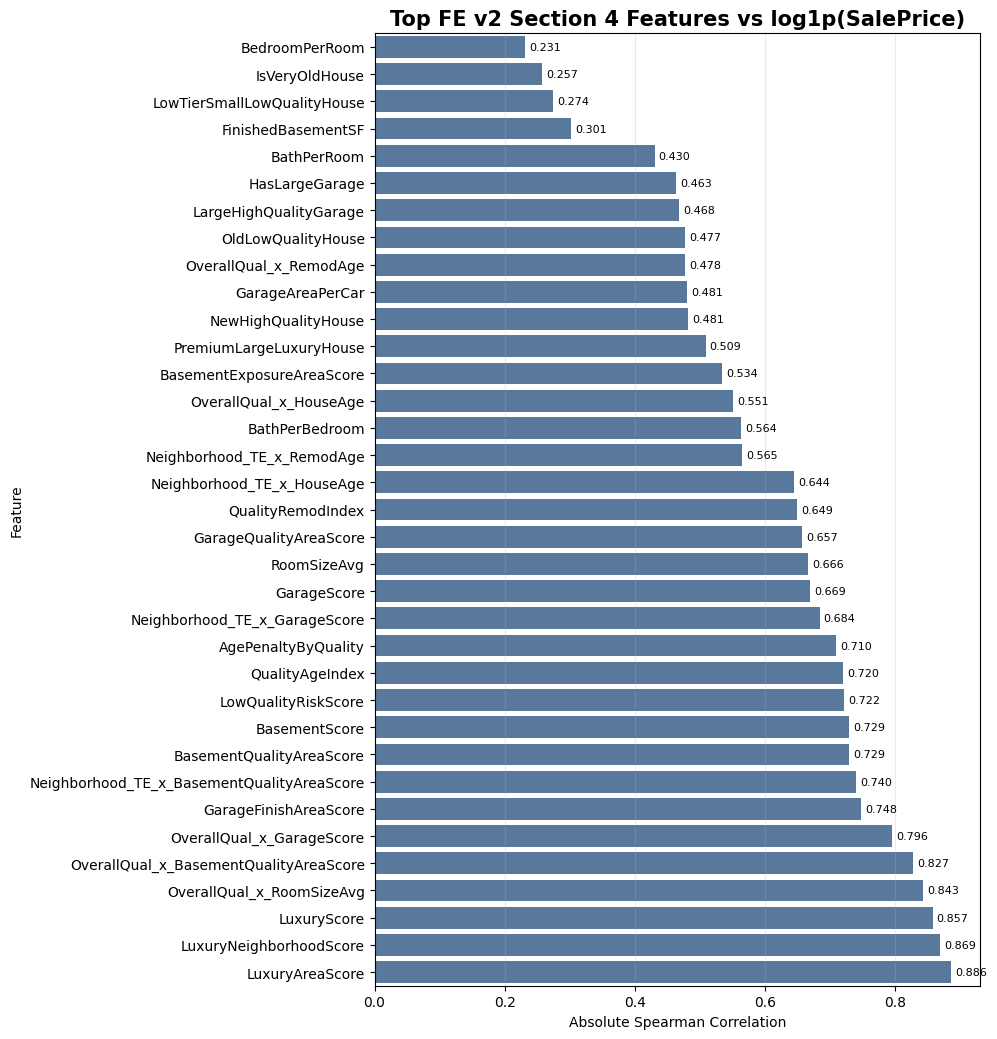

In [49]:
# ============================================================
# 4.12 Plot top Section 4 feature signal
# ============================================================

plot_df = section4_feature_signal_report.dropna(subset=["abs_spearman_corr"]).head(35).copy()

if plot_df.empty:
    print("No Section 4 numeric feature signal to plot.")
else:
    plt.figure(figsize=(10, max(6, len(plot_df) * 0.30)))

    ax = sns.barplot(
        data=plot_df.sort_values("abs_spearman_corr", ascending=True),
        x="abs_spearman_corr",
        y="feature",
        color="#4E79A7"
    )

    plt.title("Top FE v2 Section 4 Features vs log1p(SalePrice)", fontsize=15, fontweight="bold")
    plt.xlabel("Absolute Spearman Correlation")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_V2_DIR / "04_02_top_qgb_tail_feature_signal.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Missing/infinite check

In [50]:
# ============================================================
# 4.13 Missing/infinite check
# ============================================================

numeric_section4_features = [
    col for col in SECTION4_FEATURES_CREATED
    if col in X_train_v2_qgb.columns
    and pd.api.types.is_numeric_dtype(X_train_v2_qgb[col])
]

section4_quality_check = pd.DataFrame([
    {
        "feature": col,
        "train_missing": int(X_train_v2_qgb[col].isna().sum()),
        "test_missing": int(X_test_v2_qgb[col].isna().sum()),
        "train_inf": int(np.isinf(X_train_v2_qgb[col]).sum()),
        "test_inf": int(np.isinf(X_test_v2_qgb[col]).sum()),
        "train_min": X_train_v2_qgb[col].min(),
        "train_max": X_train_v2_qgb[col].max(),
        "test_min": X_test_v2_qgb[col].min(),
        "test_max": X_test_v2_qgb[col].max(),
    }
    for col in numeric_section4_features
])

section4_quality_check.to_csv(
    FE_STEP_REPORT_V2_DIR / "04_qgb_tail_quality_check.csv",
    index=False
)

section4_quality_check

,feature,train_missing,test_missing,train_inf,test_inf,train_min,train_max,test_min,test_max
0,OverallQual_x_HouseAge,0,0,0,0,0.000000,1150.000000,0.000000,960.000000
1,OverallQual_x_RemodAge,0,0,0,0,0.000000,448.000000,0.000000,464.000000
2,Neighborhood_TE_x_HouseAge,0,0,0,0,0.000000,1602.117992,0.000000,1557.522034
3,Neighborhood_TE_x_RemodAge,0,0,0,0,0.000000,735.100411,0.000000,728.997056
4,QualityAgeIndex,0,0,0,0,0.011364,10.000000,0.017544,10.000000
5,QualityRemodIndex,0,0,0,0,0.016667,10.000000,0.017544,10.000000
6,AgePenaltyByQuality,0,0,0,0,0.000000,43.500000,0.000000,33.000000
7,IsVeryOldHouse,0,0,0,0,0.000000,1.000000,0.000000,1.000000
8,IsOldButRemodeled,0,0,0,0,0.000000,1.000000,0.000000,1.000000
9,OldLowQualityHouse,0,0,0,0,0.000000,1.000000,0.000000,1.000000


### Save Section 4 checkpoint datasets

In [51]:
# ============================================================
# 4.14 Save Section 4 checkpoint datasets
# ============================================================

X_train_v2_qgb.to_csv(
    FE_RESULT_V2_DIR / "04_X_train_v2_qgb_tail_checkpoint.csv",
    index=False
)

X_test_v2_qgb.to_csv(
    FE_RESULT_V2_DIR / "04_X_test_v2_qgb_tail_checkpoint.csv",
    index=False
)

print("Saved Section 4 checkpoint datasets:")
print(FE_RESULT_V2_DIR / "04_X_train_v2_qgb_tail_checkpoint.csv")
print(FE_RESULT_V2_DIR / "04_X_test_v2_qgb_tail_checkpoint.csv")

Saved Section 4 checkpoint datasets:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\04_X_train_v2_qgb_tail_checkpoint.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\04_X_test_v2_qgb_tail_checkpoint.csv


### Final Section 4 safety check

In [52]:
# ============================================================
# 4.15 Final Section 4 safety check
# ============================================================

assert X_train_v2_qgb.shape[0] == len(y_log_v2)
assert X_test_v2_qgb.shape[0] == len(test_ids_v2)
assert X_train_v2_qgb.columns.equals(X_test_v2_qgb.columns)

train_missing_total = int(X_train_v2_qgb[numeric_section4_features].isna().sum().sum())
test_missing_total = int(X_test_v2_qgb[numeric_section4_features].isna().sum().sum())

train_inf_total = int(np.isinf(X_train_v2_qgb[numeric_section4_features]).sum().sum())
test_inf_total = int(np.isinf(X_test_v2_qgb[numeric_section4_features]).sum().sum())

if train_missing_total > 0 or test_missing_total > 0:
    raise ValueError(f"Missing values found in Section 4 features. Train={train_missing_total}, Test={test_missing_total}")

if train_inf_total > 0 or test_inf_total > 0:
    raise ValueError(f"Infinite values found in Section 4 features. Train={train_inf_total}, Test={test_inf_total}")

print("Section 4 feature creation completed safely.")
print("Created Section 4 features:", len(SECTION4_FEATURES_CREATED))
print("X_train_v2_qgb:", X_train_v2_qgb.shape)
print("X_test_v2_qgb:", X_test_v2_qgb.shape)

Section 4 feature creation completed safely.
Created Section 4 features: 39
X_train_v2_qgb: (1458, 247)
X_test_v2_qgb: (1459, 247)


### Manual Decision

Quality-age, garage, basement, room-ratio, and tail-risk features have been created.

Main decisions:

- Created quality × age/remodel interaction features.
- Created refined garage score features.
- Created refined basement score features.
- Created room/bath ratio features.
- Created luxury and low-quality risk features.
- Created tail-specific flags for premium, large, old, and low-quality houses.

These features are designed to reduce errors in:

- high-price luxury houses
- low-price risk houses
- old but remodeled houses
- large houses whose value depends on neighborhood and quality
- garage/basement quality-area combinations

Next section:

`5. Sparse Feature Cleanup and Final v2 Encoding`

## 5. Sparse Feature Cleanup and Final v2 Encoding

This section converts the FE v2 feature dataset into numeric model-ready matrices.

Main goals:

- remove unsafe / near-constant columns
- clean categorical labels
- simplify very sparse categorical features
- apply rare grouping using train data only
- one-hot encode remaining categorical features
- align train/test columns
- save encoded v2 checkpoint datasets

No model training is performed here.

### Create encoding working copies

In [53]:
# ============================================================
# 5.1 Create encoding working copies
# ============================================================

X_train_v2_encode = X_train_v2_qgb.copy()
X_test_v2_encode = X_test_v2_qgb.copy()

print("Before v2 encoding:")
print("X_train_v2_encode:", X_train_v2_encode.shape)
print("X_test_v2_encode:", X_test_v2_encode.shape)

Before v2 encoding:
X_train_v2_encode: (1458, 247)
X_test_v2_encode: (1459, 247)


### Remove ID from modeling matrix

In [54]:
# ============================================================
# 5.2 Remove Id from modeling matrix
# ============================================================

train_ids_v2_final = (
    X_train_v2_encode[ID_COL].copy()
    if ID_COL in X_train_v2_encode.columns
    else train_ids_v2.copy()
)

test_ids_v2_final = (
    X_test_v2_encode[ID_COL].copy()
    if ID_COL in X_test_v2_encode.columns
    else test_ids_v2.copy()
)

X_train_v2_encode = X_train_v2_encode.drop(columns=[ID_COL], errors="ignore")
X_test_v2_encode = X_test_v2_encode.drop(columns=[ID_COL], errors="ignore")

print("After dropping Id:")
print("X_train_v2_encode:", X_train_v2_encode.shape)
print("X_test_v2_encode:", X_test_v2_encode.shape)

After dropping Id:
X_train_v2_encode: (1458, 246)
X_test_v2_encode: (1459, 246)


### Replace risky absence labels

In [55]:
# ============================================================
# 5.3 Categorical cleanup
# ============================================================

categorical_cols_v2 = X_train_v2_encode.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for df in [X_train_v2_encode, X_test_v2_encode]:
    for col in categorical_cols_v2:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype("object")
                .fillna("Unknown")
                .astype(str)
                .replace({
                    "None": "NoFeature",
                    "nan": "Unknown",
                    "NaN": "Unknown",
                    "": "Unknown"
                })
            )

categorical_cleanup_v2_report = pd.DataFrame([
    {
        "feature": col,
        "train_unique_after_cleanup": X_train_v2_encode[col].nunique(dropna=False),
        "test_unique_after_cleanup": X_test_v2_encode[col].nunique(dropna=False),
        "train_missing_after_cleanup": int(X_train_v2_encode[col].isna().sum()),
        "test_missing_after_cleanup": int(X_test_v2_encode[col].isna().sum())
    }
    for col in categorical_cols_v2
])

categorical_cleanup_v2_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_categorical_cleanup_v2_report.csv",
    index=False
)

categorical_cleanup_v2_report

,feature,train_unique_after_cleanup,test_unique_after_cleanup,train_missing_after_cleanup,test_missing_after_cleanup
0,MSZoning,5,5,0,0
1,Street,2,2,0,0
2,Alley,3,3,0,0
3,LotShape,4,4,0,0
4,LandContour,4,4,0,0
5,Utilities,2,1,0,0
6,LotConfig,5,5,0,0
7,LandSlope,3,3,0,0
8,Neighborhood,25,25,0,0
9,Condition1,9,9,0,0


### Drop near-constant columns

In [56]:
# ============================================================
# 5.4 Drop near-constant columns
# ============================================================

near_constant_cols = []

for col in X_train_v2_encode.columns:
    train_unique = X_train_v2_encode[col].nunique(dropna=False)
    test_unique = X_test_v2_encode[col].nunique(dropna=False) if col in X_test_v2_encode.columns else 0

    if train_unique <= 1 and test_unique <= 1:
        near_constant_cols.append(col)

# Extra conservative drop list: only if columns exist and are nearly useless.
manual_always_review_cols = [
    "Utilities",
    "Street",
]

manual_drop_cols = [
    col for col in manual_always_review_cols
    if col in X_train_v2_encode.columns
    and X_train_v2_encode[col].nunique(dropna=False) <= 2
]

drop_cols_v2 = sorted(set(near_constant_cols + manual_drop_cols))

drop_column_report_v2 = pd.DataFrame([
    {
        "feature": col,
        "reason": (
            "near_constant"
            if col in near_constant_cols
            else "manual_low_signal_review"
        ),
        "train_unique": X_train_v2_encode[col].nunique(dropna=False),
        "test_unique": X_test_v2_encode[col].nunique(dropna=False) if col in X_test_v2_encode.columns else np.nan
    }
    for col in drop_cols_v2
])

X_train_v2_encode = X_train_v2_encode.drop(columns=drop_cols_v2, errors="ignore")
X_test_v2_encode = X_test_v2_encode.drop(columns=drop_cols_v2, errors="ignore")

drop_column_report_v2.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_dropped_near_constant_columns_v2.csv",
    index=False
)

print("Dropped columns:", len(drop_cols_v2))
drop_column_report_v2

Dropped columns: 2


,feature,reason,train_unique,test_unique
0,Street,manual_low_signal_review,2,2
1,Utilities,manual_low_signal_review,2,1


### Define rare grouping strategy

In [57]:
# ============================================================
# 5.5 Define rare grouping strategy
# ============================================================

RARE_GROUP_MIN_COUNT_V2 = 10

categorical_cols_v2_after_drop = X_train_v2_encode.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# More aggressive rare grouping for very sparse categorical fields.
high_sparse_categorical_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "Condition2",
    "RoofMatl",
]

rare_group_cols_v2 = [
    col for col in categorical_cols_v2_after_drop
    if col in X_train_v2_encode.columns and col in X_test_v2_encode.columns
]

print("Categorical columns for rare grouping:", len(rare_group_cols_v2))
rare_group_cols_v2

Categorical columns for rare grouping: 42


['MSZoning',
 'Alley',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition',
 'NeighborhoodPriceTier']

### Fit rare grouping from train only

In [58]:
# ============================================================
# 5.6 Fit rare grouping artifacts from train only
# ============================================================

rare_group_artifacts_v2 = {}

for col in rare_group_cols_v2:
    value_counts = X_train_v2_encode[col].value_counts(dropna=False)

    min_count = RARE_GROUP_MIN_COUNT_V2

    # Sparse columns get stronger rare grouping.
    if col in high_sparse_categorical_cols:
        min_count = 20

    keep_values = value_counts[
        value_counts >= min_count
    ].index.astype(str).tolist()

    rare_values = value_counts[
        value_counts < min_count
    ].index.astype(str).tolist()

    rare_group_artifacts_v2[col] = {
        "min_count": min_count,
        "keep_values": keep_values,
        "rare_values": rare_values,
        "train_unique_before": int(X_train_v2_encode[col].nunique(dropna=False)),
        "train_rare_value_count": len(rare_values)
    }

rare_group_v2_report = pd.DataFrame([
    {
        "feature": col,
        "min_count": artifacts["min_count"],
        "train_unique_before": artifacts["train_unique_before"],
        "keep_value_count": len(artifacts["keep_values"]),
        "rare_value_count": artifacts["train_rare_value_count"],
        "rare_values": ", ".join(artifacts["rare_values"])
    }
    for col, artifacts in rare_group_artifacts_v2.items()
])

rare_group_v2_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_rare_grouping_artifacts_v2.csv",
    index=False
)

rare_group_v2_report.sort_values("rare_value_count", ascending=False)

,feature,min_count,train_unique_before,keep_value_count,rare_value_count,rare_values
8,Condition2,20,8,1,7,"Feedr, Artery, RRNn, PosA, PosN, RRAn, RRAe"
12,RoofMatl,20,7,1,6,"Tar&Grv, WdShngl, WdShake, Metal, Membran, Roll"
39,SaleType,10,9,3,6,"ConLD, ConLI, ConLw, CWD, Oth, Con"
14,Exterior2nd,10,16,11,5,"Brk Cmn, Stone, AsphShn, Other, CBlock"
13,Exterior1st,10,15,10,5,"BrkComm, Stone, AsphShn, ImStucc, CBlock"
24,Heating,10,6,2,4,"Grav, Wall, OthW, Floor"
34,GarageCond,10,6,3,3,"Gd, Po, Ex"
36,PoolQC,20,4,1,3,"Ex, Fa, Gd"
38,MiscFeature,20,5,2,3,"Gar2, Othr, TenC"
7,Condition1,10,9,6,3,"PosA, RRNn, RRNe"


### Apply rare grouping

In [59]:
# ============================================================
# 5.7 Apply rare grouping
# ============================================================

rare_group_application_rows_v2 = []

for col, artifacts in rare_group_artifacts_v2.items():
    keep_values = set(artifacts["keep_values"])

    train_before_unique = X_train_v2_encode[col].nunique(dropna=False)
    test_before_unique = X_test_v2_encode[col].nunique(dropna=False)

    train_rare_mask = ~X_train_v2_encode[col].astype(str).isin(keep_values)
    test_rare_mask = ~X_test_v2_encode[col].astype(str).isin(keep_values)

    train_rare_count = int(train_rare_mask.sum())
    test_rare_count = int(test_rare_mask.sum())

    X_train_v2_encode.loc[train_rare_mask, col] = "Rare"
    X_test_v2_encode.loc[test_rare_mask, col] = "Rare"

    rare_group_application_rows_v2.append({
        "feature": col,
        "train_unique_before": train_before_unique,
        "train_unique_after": X_train_v2_encode[col].nunique(dropna=False),
        "test_unique_before": test_before_unique,
        "test_unique_after": X_test_v2_encode[col].nunique(dropna=False),
        "train_rows_grouped_to_rare": train_rare_count,
        "test_rows_grouped_to_rare": test_rare_count
    })

rare_group_application_v2_report = pd.DataFrame(rare_group_application_rows_v2)

rare_group_application_v2_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_rare_grouping_application_v2.csv",
    index=False
)

rare_group_application_v2_report.sort_values("train_rows_grouped_to_rare", ascending=False)

,feature,train_unique_before,train_unique_after,test_unique_before,test_unique_after,train_rows_grouped_to_rare,test_rows_grouped_to_rare
39,SaleType,9,4,9,4,28,39
12,RoofMatl,7,2,4,2,25,17
34,GarageCond,6,4,6,4,18,14
14,Exterior2nd,16,12,15,12,17,19
7,Condition1,9,7,9,7,15,20
31,GarageType,7,6,7,6,15,23
24,Heating,6,3,4,3,14,4
8,Condition2,8,2,5,2,14,15
6,Neighborhood,25,24,25,24,11,22
37,Fence,5,5,5,5,11,1


### Plot rare grouping reduction

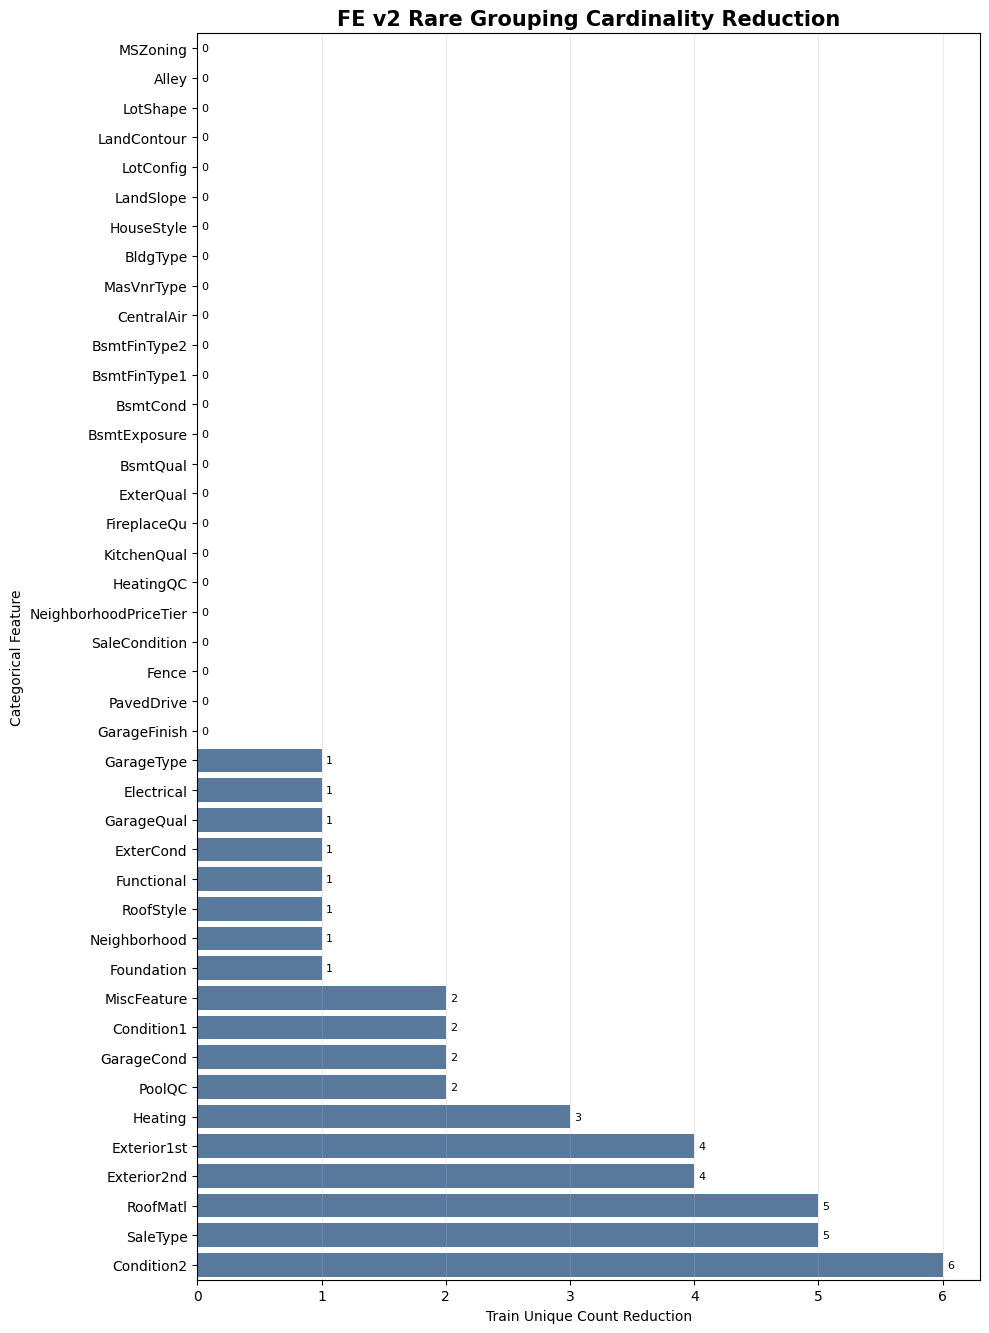

In [60]:
# ============================================================
# 5.8 Plot rare grouping reduction
# ============================================================

plot_df = rare_group_application_v2_report.copy()

if plot_df.empty:
    print("No rare grouping applied.")
else:
    plot_df["unique_reduction"] = (
        plot_df["train_unique_before"] -
        plot_df["train_unique_after"]
    )

    plot_df = plot_df.sort_values("unique_reduction", ascending=True)

    plt.figure(figsize=(10, max(5, len(plot_df) * 0.32)))

    ax = sns.barplot(
        data=plot_df,
        x="unique_reduction",
        y="feature",
        color="#4E79A7"
    )

    plt.title("FE v2 Rare Grouping Cardinality Reduction", fontsize=15, fontweight="bold")
    plt.xlabel("Train Unique Count Reduction")
    plt.ylabel("Categorical Feature")

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_V2_DIR / "05_01_rare_grouping_reduction_v2.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Handle unseen test categories

In [61]:
# ============================================================
# 5.9 Handle unseen test categories
# ============================================================

unseen_test_category_rows_v2 = []

for col in rare_group_cols_v2:
    if col not in X_train_v2_encode.columns or col not in X_test_v2_encode.columns:
        continue

    train_values = set(X_train_v2_encode[col].astype(str).unique())
    test_values = set(X_test_v2_encode[col].astype(str).unique())

    unseen_values = sorted(test_values - train_values)

    if len(unseen_values) > 0:
        unseen_mask = X_test_v2_encode[col].astype(str).isin(unseen_values)

        X_test_v2_encode.loc[unseen_mask, col] = "Rare"

        unseen_test_category_rows_v2.append({
            "feature": col,
            "unseen_values": ", ".join(unseen_values),
            "unseen_row_count": int(unseen_mask.sum()),
            "replacement": "Rare"
        })

unseen_test_category_v2_report = pd.DataFrame(unseen_test_category_rows_v2)

unseen_test_category_v2_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_unseen_test_category_v2_report.csv",
    index=False
)

unseen_test_category_v2_report

""


### **One-hot encode categorical columns**

In [62]:
# ============================================================
# 5.10 One-hot encode categorical columns
# ============================================================

categorical_cols_for_ohe_v2 = X_train_v2_encode.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for df in [X_train_v2_encode, X_test_v2_encode]:
    for col in categorical_cols_for_ohe_v2:
        if col in df.columns:
            df[col] = df[col].astype(str)

X_train_v2_encoded = pd.get_dummies(
    X_train_v2_encode,
    columns=categorical_cols_for_ohe_v2,
    prefix_sep="__",
    dummy_na=False,
    dtype=np.uint8
)

X_test_v2_encoded = pd.get_dummies(
    X_test_v2_encode,
    columns=categorical_cols_for_ohe_v2,
    prefix_sep="__",
    dummy_na=False,
    dtype=np.uint8
)

# Align test to train columns.
X_test_v2_encoded = X_test_v2_encoded.reindex(
    columns=X_train_v2_encoded.columns,
    fill_value=0
)

print("After v2 one-hot encoding:")
print("X_train_v2_encoded:", X_train_v2_encoded.shape)
print("X_test_v2_encoded:", X_test_v2_encoded.shape)

After v2 one-hot encoding:
X_train_v2_encoded: (1458, 424)
X_test_v2_encoded: (1459, 424)


### **Remove duplicate / all-zero columns**

In [63]:
# ============================================================
# 5.11 Remove duplicate / all-zero columns
# ============================================================

duplicate_cols_v2 = X_train_v2_encoded.columns[
    X_train_v2_encoded.columns.duplicated()
].tolist()

all_zero_cols_v2 = [
    col for col in X_train_v2_encoded.columns
    if X_train_v2_encoded[col].sum() == 0 and X_test_v2_encoded[col].sum() == 0
]

post_encoding_drop_cols_v2 = sorted(set(duplicate_cols_v2 + all_zero_cols_v2))

X_train_v2_encoded = X_train_v2_encoded.drop(columns=post_encoding_drop_cols_v2, errors="ignore")
X_test_v2_encoded = X_test_v2_encoded.drop(columns=post_encoding_drop_cols_v2, errors="ignore")

post_encoding_drop_report_v2 = pd.DataFrame([
    {
        "feature": col,
        "reason": (
            "duplicate_column"
            if col in duplicate_cols_v2
            else "all_zero_train_and_test"
        )
    }
    for col in post_encoding_drop_cols_v2
])

post_encoding_drop_report_v2.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_post_encoding_dropped_columns_v2.csv",
    index=False
)

print("Post-encoding dropped columns:", len(post_encoding_drop_cols_v2))
post_encoding_drop_report_v2

Post-encoding dropped columns: 0


""


### Encoding summary report

In [64]:
# ============================================================
# 5.12 Encoding summary report
# ============================================================

encoding_summary_v2 = pd.DataFrame([
    {
        "stage": "before_encoding",
        "train_rows": X_train_v2_encode.shape[0],
        "test_rows": X_test_v2_encode.shape[0],
        "train_columns": X_train_v2_encode.shape[1],
        "test_columns": X_test_v2_encode.shape[1],
        "categorical_columns": len(categorical_cols_for_ohe_v2),
        "numeric_columns": X_train_v2_encode.shape[1] - len(categorical_cols_for_ohe_v2)
    },
    {
        "stage": "after_encoding",
        "train_rows": X_train_v2_encoded.shape[0],
        "test_rows": X_test_v2_encoded.shape[0],
        "train_columns": X_train_v2_encoded.shape[1],
        "test_columns": X_test_v2_encoded.shape[1],
        "categorical_columns": 0,
        "numeric_columns": X_train_v2_encoded.shape[1]
    }
])

encoding_summary_v2.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_encoding_summary_v2.csv",
    index=False
)

encoding_summary_v2

,stage,train_rows,test_rows,train_columns,test_columns,categorical_columns,numeric_columns
0,before_encoding,1458,1459,244,244,42,202
1,after_encoding,1458,1459,424,424,0,424


### One-hot group report

In [65]:
# ============================================================
# 5.13 One-hot group report
# ============================================================

onehot_group_rows_v2 = []

for original_col in categorical_cols_for_ohe_v2:
    prefix = original_col + "__"
    created_cols = [
        col for col in X_train_v2_encoded.columns
        if col.startswith(prefix)
    ]

    onehot_group_rows_v2.append({
        "original_feature": original_col,
        "onehot_column_count": len(created_cols),
        "onehot_columns": ", ".join(created_cols)
    })

onehot_group_report_v2 = pd.DataFrame(onehot_group_rows_v2).sort_values(
    "onehot_column_count",
    ascending=False
).reset_index(drop=True)

onehot_group_report_v2.to_csv(
    FE_STEP_REPORT_V2_DIR / "05_onehot_group_report_v2.csv",
    index=False
)

onehot_group_report_v2.head(30)

,original_feature,onehot_column_count,onehot_columns
0,Neighborhood,24,"Neighborhood__Blmngtn, Neighborhood__BrDale, N..."
1,Exterior2nd,12,"Exterior2nd__AsbShng, Exterior2nd__BrkFace, Ex..."
2,Exterior1st,11,"Exterior1st__AsbShng, Exterior1st__BrkFace, Ex..."
3,HouseStyle,8,"HouseStyle__1.5Fin, HouseStyle__1.5Unf, HouseS..."
4,BsmtFinType2,7,"BsmtFinType2__ALQ, BsmtFinType2__BLQ, BsmtFinT..."
5,BsmtFinType1,7,"BsmtFinType1__ALQ, BsmtFinType1__BLQ, BsmtFinT..."
6,Condition1,7,"Condition1__Artery, Condition1__Feedr, Conditi..."
7,Functional,6,"Functional__Maj1, Functional__Min1, Functional..."
8,GarageType,6,"GarageType__Attchd, GarageType__Basment, Garag..."
9,FireplaceQu,6,"FireplaceQu__Ex, FireplaceQu__Fa, FireplaceQu_..."


### Plot one-hot column contribution

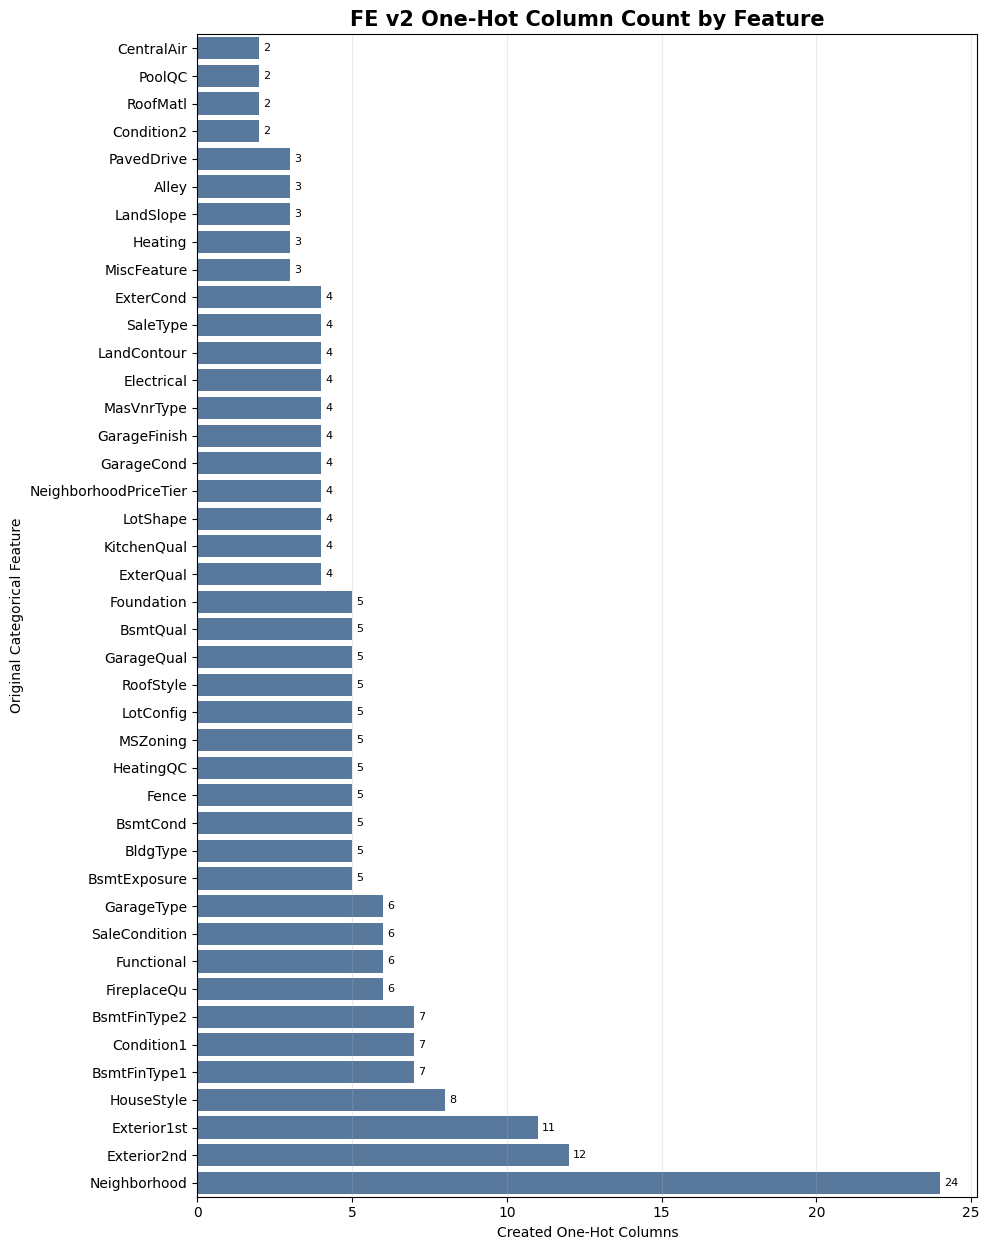

In [66]:
# ============================================================
# 5.14 Plot one-hot column contribution
# ============================================================

plot_df = onehot_group_report_v2.sort_values("onehot_column_count", ascending=True)

plt.figure(figsize=(10, max(6, len(plot_df) * 0.30)))

ax = sns.barplot(
    data=plot_df,
    x="onehot_column_count",
    y="original_feature",
    color="#4E79A7"
)

plt.title("FE v2 One-Hot Column Count by Feature", fontsize=15, fontweight="bold")
plt.xlabel("Created One-Hot Columns")
plt.ylabel("Original Categorical Feature")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=8)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FE_PLOT_V2_DIR / "05_02_onehot_column_count_v2.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### Save encoding artifacts

In [67]:
# ============================================================
# 5.15 Save encoding artifacts
# ============================================================

encoding_artifacts_v2 = {
    "dropped_columns_before_encoding": drop_cols_v2,
    "post_encoding_dropped_columns": post_encoding_drop_cols_v2,
    "categorical_cols_for_ohe": categorical_cols_for_ohe_v2,
    "rare_group_min_count": RARE_GROUP_MIN_COUNT_V2,
    "rare_group_artifacts": rare_group_artifacts_v2,
    "encoded_columns": X_train_v2_encoded.columns.tolist(),
    "absence_label_used": "NoFeature",
    "target_encoding_artifacts_path": str(FE_RESULT_V2_DIR / "02_target_encoding_artifacts.joblib"),
}

joblib.dump(
    encoding_artifacts_v2,
    FE_RESULT_V2_DIR / "05_encoding_artifacts_v2.joblib"
)

print("Saved v2 encoding artifacts:")
print(FE_RESULT_V2_DIR / "05_encoding_artifacts_v2.joblib")

Saved v2 encoding artifacts:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\05_encoding_artifacts_v2.joblib


### Save encoded v2 checkpoint

In [68]:
# ============================================================
# 5.16 Save encoded v2 checkpoint
# ============================================================

X_train_v2_encoded.to_csv(
    FE_RESULT_V2_DIR / "05_X_train_v2_encoded_checkpoint.csv",
    index=False
)

X_test_v2_encoded.to_csv(
    FE_RESULT_V2_DIR / "05_X_test_v2_encoded_checkpoint.csv",
    index=False
)

print("Saved encoded v2 checkpoint datasets:")
print(FE_RESULT_V2_DIR / "05_X_train_v2_encoded_checkpoint.csv")
print(FE_RESULT_V2_DIR / "05_X_test_v2_encoded_checkpoint.csv")

Saved encoded v2 checkpoint datasets:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\05_X_train_v2_encoded_checkpoint.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\05_X_test_v2_encoded_checkpoint.csv


### Final encoded safety check

In [69]:
# ============================================================
# 5.17 Final encoded safety check
# ============================================================

assert X_train_v2_encoded.shape[0] == len(y_log_v2)
assert X_test_v2_encoded.shape[0] == len(test_ids_v2)
assert X_train_v2_encoded.columns.equals(X_test_v2_encoded.columns)

train_missing_total = int(X_train_v2_encoded.isna().sum().sum())
test_missing_total = int(X_test_v2_encoded.isna().sum().sum())

train_object_cols = X_train_v2_encoded.select_dtypes(include=["object", "category"]).columns.tolist()
test_object_cols = X_test_v2_encoded.select_dtypes(include=["object", "category"]).columns.tolist()

train_inf_total = int(np.isinf(X_train_v2_encoded.select_dtypes(include=[np.number])).sum().sum())
test_inf_total = int(np.isinf(X_test_v2_encoded.select_dtypes(include=[np.number])).sum().sum())

if train_missing_total > 0 or test_missing_total > 0:
    raise ValueError(f"Missing values remain after v2 encoding. Train={train_missing_total}, Test={test_missing_total}")

if len(train_object_cols) > 0 or len(test_object_cols) > 0:
    raise ValueError(f"Object columns remain after v2 encoding. Train={train_object_cols}, Test={test_object_cols}")

if train_inf_total > 0 or test_inf_total > 0:
    raise ValueError(f"Infinite values remain after v2 encoding. Train={train_inf_total}, Test={test_inf_total}")

print("FE v2 encoding completed safely.")
print("X_train_v2_encoded:", X_train_v2_encoded.shape)
print("X_test_v2_encoded:", X_test_v2_encoded.shape)

FE v2 encoding completed safely.
X_train_v2_encoded: (1458, 424)
X_test_v2_encoded: (1459, 424)


### Manual Decision

Sparse feature cleanup and final v2 encoding are complete.

Main decisions:

- `Id` was removed from the modeling matrix.
- Risky absence label `"None"` was replaced with `"NoFeature"`.
- Near-constant columns were removed.
- Rare grouping was applied using train data only.
- Sparse categorical features were grouped more aggressively.
- Unseen test categories were mapped to `"Rare"`.
- All categorical features were one-hot encoded.
- Train/test encoded columns were aligned.
- Encoded checkpoint datasets were saved.

This encoded matrix is now ready for creating:

- tree-based v2 final dataset
- linear v2 final dataset
- final validation/export files

Next section:

`6. Create Final v2 Tree and Linear Datasets`

## 6. Create Final v2 Tree and Linear Datasets

This section creates the final FE v2 model-ready datasets.

Main outputs:

- tree-based v2 dataset
- linear-model v2 dataset
- final target files
- final ID files
- feature lists
- validation reports

Important:

No model training is performed here.

### Create final tree dataset

In [70]:
# ============================================================
# 6.1 Create final tree-based v2 dataset
# ============================================================

X_train_tree_v2_final = X_train_v2_encoded.copy()
X_test_tree_v2_final = X_test_v2_encoded.copy()

print("Tree v2 final dataset:")
print("X_train_tree_v2_final:", X_train_tree_v2_final.shape)
print("X_test_tree_v2_final:", X_test_tree_v2_final.shape)

Tree v2 final dataset:
X_train_tree_v2_final: (1458, 424)
X_test_tree_v2_final: (1459, 424)


### Define linear v2 log-transform candidates

In [71]:
# ============================================================
# 6.2 Define linear v2 log-transform candidates
# ============================================================

LINEAR_V2_LOG_TRANSFORM_CANDIDATES = [
    # raw area / size
    "LotFrontage",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",

    # v1 engineered size
    "TotalSF",
    "LivingPlusBasementSF",
    "TotalPorchSF",
    "OutdoorSF",
    "TotalBath",

    # v1/v2 interactions with large magnitude
    "OverallQual_x_TotalSF",
    "OverallQual_x_GrLivArea",
    "OverallQual_x_TotalBath",
    "KitchenQual_Ord_x_GrLivArea",
    "ExterQual_Ord_x_GrLivArea",
    "BsmtQual_Ord_x_TotalBsmtSF",
    "GarageFinish_Ord_x_GarageArea",
    "GarageQual_Ord_x_GarageArea",

    # v2 location-size interactions
    "Neighborhood_TE_x_GrLivArea",
    "Neighborhood_TE_x_TotalSF",
    "Neighborhood_TE_x_LivingPlusBasementSF",
    "Neighborhood_TE_x_TotalBsmtSF",
    "Neighborhood_TE_x_1stFlrSF",
    "Neighborhood_TE_x_2ndFlrSF",
    "Neighborhood_TE_x_GarageArea",
    "Neighborhood_TE_x_TotalBath",
    "Neighborhood_TE_x_TotalPorchSF",
    "Neighborhood_TE_x_OutdoorSF",
    "Neighborhood_TE_x_LotArea",
    "Neighborhood_TE_x_LotFrontage",

    # v2 garage / basement scores
    "GarageScore",
    "GarageAreaPerCar",
    "GarageQualityAreaScore",
    "GarageFinishAreaScore",
    "OverallQual_x_GarageScore",
    "Neighborhood_TE_x_GarageScore",
    "BasementScore",
    "BasementQualityAreaScore",
    "BasementExposureAreaScore",
    "FinishedBasementSF",
    "OverallQual_x_BasementQualityAreaScore",
    "Neighborhood_TE_x_BasementQualityAreaScore",

    # v2 room / luxury scores
    "RoomSizeAvg",
    "OverallQual_x_RoomSizeAvg",
    "LuxuryAreaScore",
    "LuxuryNeighborhoodScore",
]

linear_v2_log_candidates_existing = [
    col for col in LINEAR_V2_LOG_TRANSFORM_CANDIDATES
    if col in X_train_v2_encoded.columns and col in X_test_v2_encoded.columns
]

print("Existing linear v2 log-transform candidates:", len(linear_v2_log_candidates_existing))
linear_v2_log_candidates_existing

Existing linear v2 log-transform candidates: 60


['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'TotalSF',
 'LivingPlusBasementSF',
 'TotalPorchSF',
 'OutdoorSF',
 'TotalBath',
 'OverallQual_x_TotalSF',
 'OverallQual_x_GrLivArea',
 'OverallQual_x_TotalBath',
 'KitchenQual_Ord_x_GrLivArea',
 'ExterQual_Ord_x_GrLivArea',
 'BsmtQual_Ord_x_TotalBsmtSF',
 'GarageFinish_Ord_x_GarageArea',
 'GarageQual_Ord_x_GarageArea',
 'Neighborhood_TE_x_GrLivArea',
 'Neighborhood_TE_x_TotalSF',
 'Neighborhood_TE_x_LivingPlusBasementSF',
 'Neighborhood_TE_x_TotalBsmtSF',
 'Neighborhood_TE_x_1stFlrSF',
 'Neighborhood_TE_x_2ndFlrSF',
 'Neighborhood_TE_x_GarageArea',
 'Neighborhood_TE_x_TotalBath',
 'Neighborhood_TE_x_TotalPorchSF',
 'Neighborhood_TE_x_OutdoorSF',
 'Neighborhood_TE_x_LotArea',
 'Neighborhood_TE_x_LotFrontage',
 

### Create final linear dataset with selected log transforms

In [72]:
# ============================================================
# 6.3 Create final linear v2 dataset with log1p transforms
# ============================================================

X_train_linear_v2_final = X_train_v2_encoded.copy()
X_test_linear_v2_final = X_test_v2_encoded.copy()

linear_v2_transform_rows = []
linear_v2_log_features_applied = []

for col in linear_v2_log_candidates_existing:
    train_min = X_train_linear_v2_final[col].min()
    test_min = X_test_linear_v2_final[col].min()

    train_unique = X_train_linear_v2_final[col].nunique(dropna=True)

    eligible = (
        pd.api.types.is_numeric_dtype(X_train_linear_v2_final[col]) and
        pd.api.types.is_numeric_dtype(X_test_linear_v2_final[col]) and
        train_min >= 0 and
        test_min >= 0 and
        train_unique > 1
    )

    row = {
        "feature": col,
        "train_min": train_min,
        "test_min": test_min,
        "train_max": X_train_linear_v2_final[col].max(),
        "test_max": X_test_linear_v2_final[col].max(),
        "train_skew_before": X_train_linear_v2_final[col].skew(),
        "eligible_for_log1p": eligible,
    }

    if eligible:
        X_train_linear_v2_final[col] = np.log1p(X_train_linear_v2_final[col])
        X_test_linear_v2_final[col] = np.log1p(X_test_linear_v2_final[col])

        row["transformation"] = "log1p in-place"
        row["train_skew_after"] = X_train_linear_v2_final[col].skew()

        linear_v2_log_features_applied.append(col)
    else:
        row["transformation"] = "not_applied"
        row["train_skew_after"] = np.nan

    linear_v2_transform_rows.append(row)

linear_v2_log_transform_report = pd.DataFrame(linear_v2_transform_rows).sort_values(
    "train_skew_before",
    ascending=False
).reset_index(drop=True)

linear_v2_log_transform_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "06_linear_v2_log_transform_report.csv",
    index=False
)

print("Linear v2 log features applied:", len(linear_v2_log_features_applied))
linear_v2_log_transform_report.head(40)

Linear v2 log features applied: 60


,feature,train_min,test_min,train_max,test_max,train_skew_before,eligible_for_log1p,transformation,train_skew_after
0,MiscVal,0.000000,0.000000,1.550000e+04,17000.000000,24.460085,True,log1p in-place,5.166779
1,PoolArea,0.000000,0.000000,7.380000e+02,800.000000,15.948945,True,log1p in-place,15.517685
2,Neighborhood_TE_x_LotArea,15620.427225,17304.178968,2.630872e+06,659355.869710,12.602345,True,log1p in-place,-0.170258
3,LotArea,1300.000000,1470.000000,2.152450e+05,56600.000000,12.573925,True,log1p in-place,-0.181278
4,3SsnPorch,0.000000,0.000000,5.080000e+02,360.000000,10.297106,True,log1p in-place,7.729423
5,LowQualFinSF,0.000000,0.000000,5.720000e+02,1064.000000,9.004955,True,log1p in-place,7.454943
6,BsmtFinSF2,0.000000,0.000000,1.474000e+03,1526.000000,4.251925,True,log1p in-place,2.521222
7,ScreenPorch,0.000000,0.000000,4.800000e+02,576.000000,4.118929,True,log1p in-place,3.147639
8,EnclosedPorch,0.000000,0.000000,5.520000e+02,1012.000000,3.087164,True,log1p in-place,2.109967
9,MasVnrArea,0.000000,0.000000,1.600000e+03,1290.000000,2.696329,True,log1p in-place,0.506312


### Plot linear v2 skewness before/after

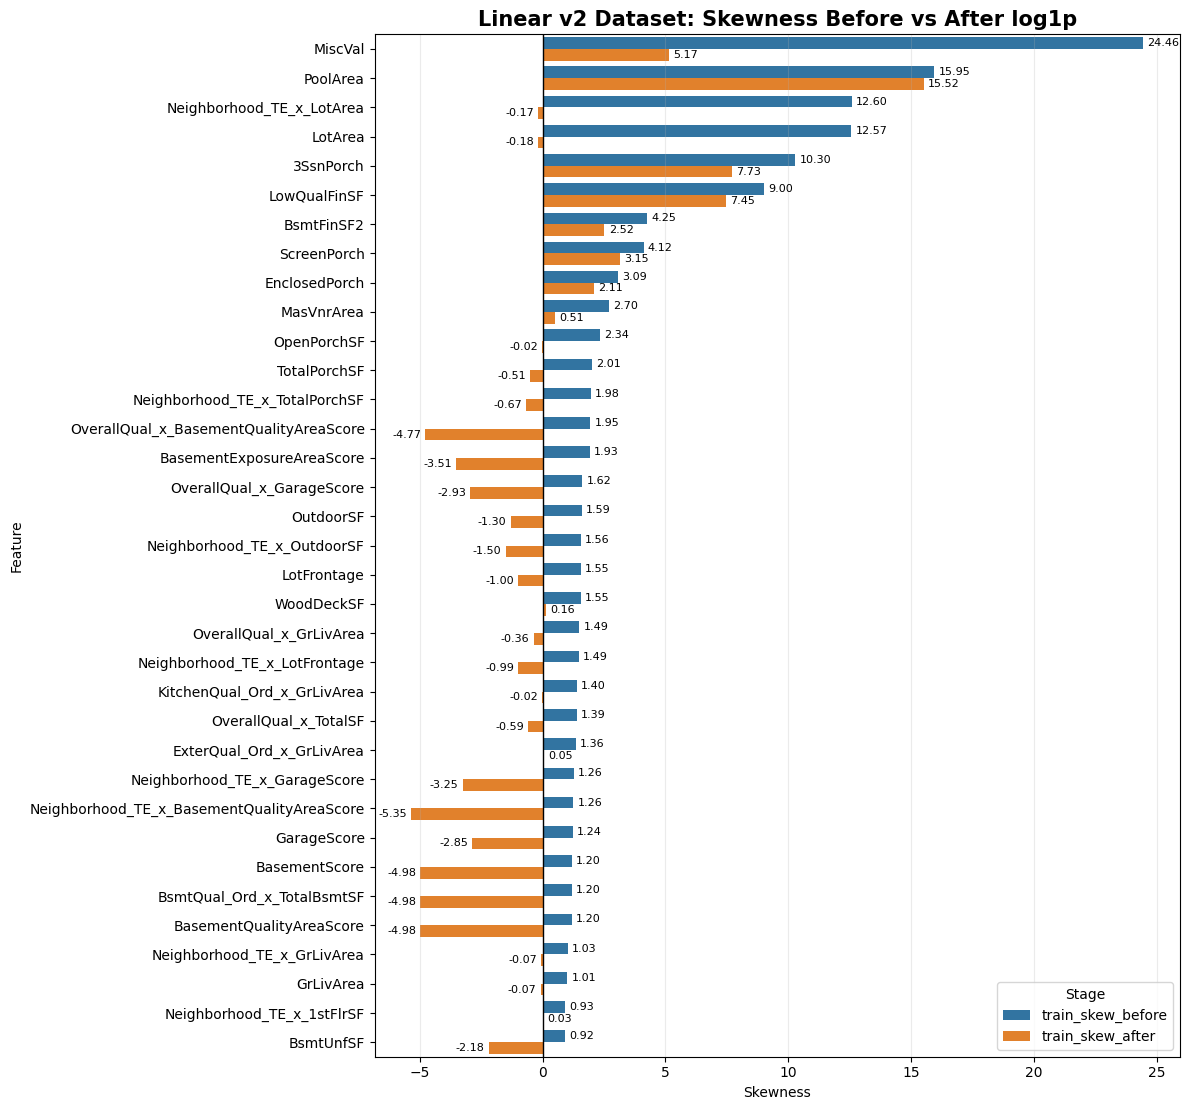

In [73]:
# ============================================================
# 6.4 Plot linear v2 skewness before/after
# ============================================================

plot_df = linear_v2_log_transform_report.loc[
    linear_v2_log_transform_report["transformation"] == "log1p in-place"
].copy()

if plot_df.empty:
    print("No log1p transformations applied.")
else:
    plot_df = plot_df.head(35)

    skew_plot = plot_df[
        ["feature", "train_skew_before", "train_skew_after"]
    ].melt(
        id_vars="feature",
        var_name="stage",
        value_name="skewness"
    )

    plt.figure(figsize=(12, max(6, len(plot_df) * 0.32)))

    ax = sns.barplot(
        data=skew_plot,
        x="skewness",
        y="feature",
        hue="stage"
    )

    plt.axvline(0, color="black", linewidth=1)
    plt.title("Linear v2 Dataset: Skewness Before vs After log1p", fontsize=15, fontweight="bold")
    plt.xlabel("Skewness")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.legend(title="Stage")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_V2_DIR / "06_01_linear_v2_skewness_before_after.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Feature group tagging helper

In [74]:
# ============================================================
# 6.5 Feature group tagging helper
# ============================================================

def tag_v2_feature_group(col, linear_log_features=None):
    if linear_log_features is None:
        linear_log_features = []

    if col in linear_log_features:
        return "log_transformed_numeric"
    if col.endswith("_TE") or col.endswith("_TE_Centered"):
        return "target_encoding"
    if "Neighborhood_TE_x_" in col or "_x_Neighborhood_TE" in col:
        return "location_interaction"
    if col in [
        "NeighborhoodPriceTier_Ord",
        "IsPremiumNeighborhood",
        "IsLowPriceNeighborhood",
        "PremiumNeighborhoodLargeHouse",
        "PremiumNeighborhoodHighQuality",
        "LowPriceNeighborhoodLargeHouse",
        "LowPriceNeighborhoodLowQuality",
        "LargeHighQualityHouse",
        "LargeLowQualityHouse",
    ]:
        return "location_tier_or_flag"
    if col.endswith("_Ord"):
        return "ordinal_score"
    if "__" in col:
        return "onehot_categorical"
    if col.startswith("Has") or col.startswith("Is"):
        return "binary_indicator"
    if "_x_" in col:
        return "interaction_feature"
    if col in [
        "LuxuryScore",
        "LuxuryAreaScore",
        "LuxuryNeighborhoodScore",
        "LowQualityRiskScore",
        "PremiumLargeLuxuryHouse",
        "LowTierSmallLowQualityHouse",
        "LargeButLowQualityRisk",
    ]:
        return "tail_luxury_risk"
    if col in [
        "GarageScore",
        "GarageAreaPerCar",
        "GarageQualityAreaScore",
        "GarageFinishAreaScore",
    ]:
        return "garage_refined"
    if col in [
        "BasementScore",
        "BasementQualityAreaScore",
        "BasementExposureAreaScore",
        "FinishedBasementSF",
        "FinishedBasementRatio",
        "UnfinishedBasementRatio",
    ]:
        return "basement_refined"
    if col in [
        "QualityAgeIndex",
        "QualityRemodIndex",
        "AgePenaltyByQuality",
        "IsVeryOldHouse",
        "IsOldButRemodeled",
        "OldLowQualityHouse",
        "NewHighQualityHouse",
    ]:
        return "quality_age"
    return "raw_or_other_numeric"


print("Feature group tagging helper ready.")

Feature group tagging helper ready.


### Tree v2 feature group report

In [75]:
# ============================================================
# 6.6 Tree v2 feature group report
# ============================================================

tree_v2_feature_rows = []

for col in X_train_tree_v2_final.columns:
    tree_v2_feature_rows.append({
        "feature": col,
        "feature_group": tag_v2_feature_group(col),
        "dtype": str(X_train_tree_v2_final[col].dtype),
        "train_missing": int(X_train_tree_v2_final[col].isna().sum()),
        "test_missing": int(X_test_tree_v2_final[col].isna().sum()),
        "train_unique": int(X_train_tree_v2_final[col].nunique(dropna=True)),
        "test_unique": int(X_test_tree_v2_final[col].nunique(dropna=True)),
    })

tree_v2_feature_group_report = pd.DataFrame(tree_v2_feature_rows)

tree_v2_feature_group_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "06_tree_v2_feature_group_report.csv",
    index=False
)

tree_v2_feature_group_summary = (
    tree_v2_feature_group_report
    .groupby("feature_group")
    .agg(
        feature_count=("feature", "count"),
        train_missing_total=("train_missing", "sum"),
        test_missing_total=("test_missing", "sum")
    )
    .reset_index()
    .sort_values("feature_count", ascending=False)
)

tree_v2_feature_group_summary.to_csv(
    FE_STEP_REPORT_V2_DIR / "06_tree_v2_feature_group_summary.csv",
    index=False
)

tree_v2_feature_group_summary

,feature_group,feature_count,train_missing_total,test_missing_total
6,onehot_categorical,222,0,0
9,raw_or_other_numeric,56,0,0
11,target_encoding,48,0,0
7,ordinal_score,19,0,0
1,binary_indicator,18,0,0
4,location_interaction,17,0,0
3,interaction_feature,13,0,0
5,location_tier_or_flag,9,0,0
10,tail_luxury_risk,7,0,0
0,basement_refined,6,0,0


### Linear v2 feature group report

In [76]:
# ============================================================
# 6.7 Linear v2 feature group report
# ============================================================

linear_v2_feature_rows = []

for col in X_train_linear_v2_final.columns:
    linear_v2_feature_rows.append({
        "feature": col,
        "feature_group": tag_v2_feature_group(
            col,
            linear_log_features=linear_v2_log_features_applied
        ),
        "dtype": str(X_train_linear_v2_final[col].dtype),
        "train_missing": int(X_train_linear_v2_final[col].isna().sum()),
        "test_missing": int(X_test_linear_v2_final[col].isna().sum()),
        "train_unique": int(X_train_linear_v2_final[col].nunique(dropna=True)),
        "test_unique": int(X_test_linear_v2_final[col].nunique(dropna=True)),
    })

linear_v2_feature_group_report = pd.DataFrame(linear_v2_feature_rows)

linear_v2_feature_group_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "06_linear_v2_feature_group_report.csv",
    index=False
)

linear_v2_feature_group_summary = (
    linear_v2_feature_group_report
    .groupby("feature_group")
    .agg(
        feature_count=("feature", "count"),
        train_missing_total=("train_missing", "sum"),
        test_missing_total=("test_missing", "sum")
    )
    .reset_index()
    .sort_values("feature_count", ascending=False)
)

linear_v2_feature_group_summary.to_csv(
    FE_STEP_REPORT_V2_DIR / "06_linear_v2_feature_group_summary.csv",
    index=False
)

linear_v2_feature_group_summary

,feature_group,feature_count,train_missing_total,test_missing_total
6,onehot_categorical,222,0,0
5,log_transformed_numeric,60,0,0
11,target_encoding,48,0,0
9,raw_or_other_numeric,31,0,0
7,ordinal_score,19,0,0
1,binary_indicator,18,0,0
4,location_tier_or_flag,9,0,0
8,quality_age,5,0,0
10,tail_luxury_risk,5,0,0
3,location_interaction,3,0,0


### Plot v2 final feature group summary

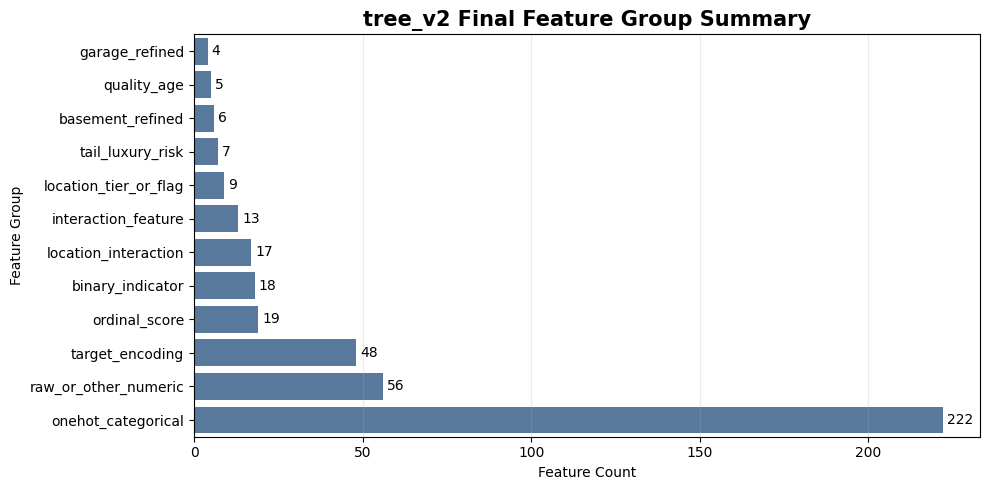

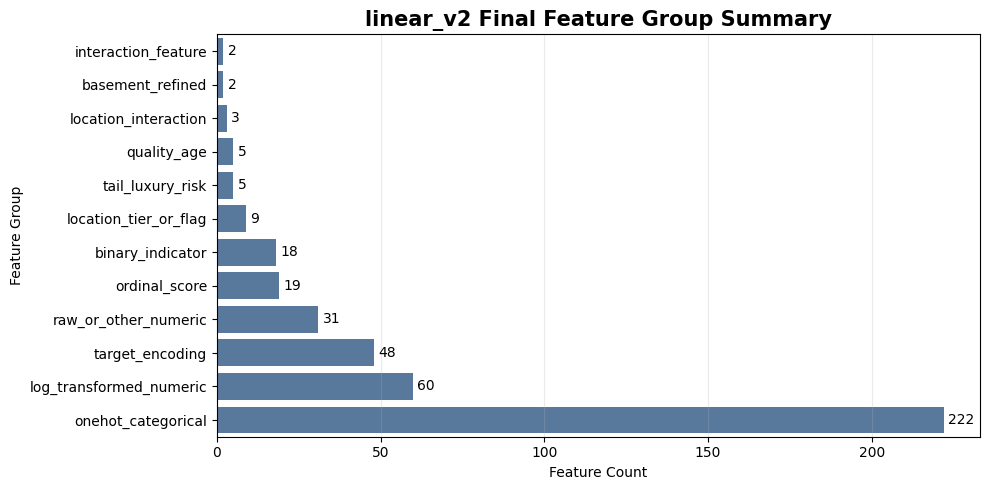

In [77]:
# ============================================================
# 6.8 Plot v2 final feature group summaries
# ============================================================

for name, summary_df in [
    ("tree_v2", tree_v2_feature_group_summary),
    ("linear_v2", linear_v2_feature_group_summary),
]:
    plot_df = summary_df.sort_values("feature_count", ascending=True)

    plt.figure(figsize=(10, max(5, len(plot_df) * 0.35)))

    ax = sns.barplot(
        data=plot_df,
        x="feature_count",
        y="feature_group",
        color="#4E79A7"
    )

    plt.title(f"{name} Final Feature Group Summary", fontsize=15, fontweight="bold")
    plt.xlabel("Feature Count")
    plt.ylabel("Feature Group")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_V2_DIR / f"06_02_{name}_feature_group_summary.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Final validation helper

In [78]:
# ============================================================
# 6.9 Final validation helper
# ============================================================

def validate_final_v2_dataset(dataset_name, X_train, X_test, y_train, test_ids):
    numeric_train = X_train.select_dtypes(include=[np.number])
    numeric_test = X_test.select_dtypes(include=[np.number])

    rows = [
        {
            "dataset": dataset_name,
            "check": "train_rows_match_target",
            "value": X_train.shape[0],
            "expected": len(y_train),
            "status": "pass" if X_train.shape[0] == len(y_train) else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "test_rows_match_test_ids",
            "value": X_test.shape[0],
            "expected": len(test_ids),
            "status": "pass" if X_test.shape[0] == len(test_ids) else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "train_test_same_columns",
            "value": X_train.columns.equals(X_test.columns),
            "expected": True,
            "status": "pass" if X_train.columns.equals(X_test.columns) else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "train_missing_total",
            "value": int(X_train.isna().sum().sum()),
            "expected": 0,
            "status": "pass" if int(X_train.isna().sum().sum()) == 0 else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "test_missing_total",
            "value": int(X_test.isna().sum().sum()),
            "expected": 0,
            "status": "pass" if int(X_test.isna().sum().sum()) == 0 else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "train_object_columns",
            "value": len(X_train.select_dtypes(include=["object", "category"]).columns),
            "expected": 0,
            "status": "pass" if len(X_train.select_dtypes(include=["object", "category"]).columns) == 0 else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "test_object_columns",
            "value": len(X_test.select_dtypes(include=["object", "category"]).columns),
            "expected": 0,
            "status": "pass" if len(X_test.select_dtypes(include=["object", "category"]).columns) == 0 else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "train_infinite_total",
            "value": int(np.isinf(numeric_train).sum().sum()),
            "expected": 0,
            "status": "pass" if int(np.isinf(numeric_train).sum().sum()) == 0 else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "test_infinite_total",
            "value": int(np.isinf(numeric_test).sum().sum()),
            "expected": 0,
            "status": "pass" if int(np.isinf(numeric_test).sum().sum()) == 0 else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "duplicate_columns_train",
            "value": int(X_train.columns.duplicated().sum()),
            "expected": 0,
            "status": "pass" if int(X_train.columns.duplicated().sum()) == 0 else "fail"
        },
        {
            "dataset": dataset_name,
            "check": "duplicate_columns_test",
            "value": int(X_test.columns.duplicated().sum()),
            "expected": 0,
            "status": "pass" if int(X_test.columns.duplicated().sum()) == 0 else "fail"
        },
    ]

    return pd.DataFrame(rows)


print("Final v2 validation helper ready.")

Final v2 validation helper ready.


### Run final v2 validation

In [79]:
# ============================================================
# 6.10 Run final v2 validation
# ============================================================

tree_v2_validation = validate_final_v2_dataset(
    dataset_name="tree_v2_final",
    X_train=X_train_tree_v2_final,
    X_test=X_test_tree_v2_final,
    y_train=y_log_v2,
    test_ids=test_ids_v2_final
)

linear_v2_validation = validate_final_v2_dataset(
    dataset_name="linear_v2_final",
    X_train=X_train_linear_v2_final,
    X_test=X_test_linear_v2_final,
    y_train=y_log_v2,
    test_ids=test_ids_v2_final
)

final_v2_validation_report = pd.concat(
    [tree_v2_validation, linear_v2_validation],
    ignore_index=True
)

final_v2_validation_report.to_csv(
    FE_STEP_REPORT_V2_DIR / "06_final_v2_validation_report.csv",
    index=False
)

final_v2_validation_report

,dataset,check,value,expected,status
0,tree_v2_final,train_rows_match_target,1458,1458,pass
1,tree_v2_final,test_rows_match_test_ids,1459,1459,pass
2,tree_v2_final,train_test_same_columns,True,True,pass
3,tree_v2_final,train_missing_total,0,0,pass
4,tree_v2_final,test_missing_total,0,0,pass
5,tree_v2_final,train_object_columns,0,0,pass
6,tree_v2_final,test_object_columns,0,0,pass
7,tree_v2_final,train_infinite_total,0,0,pass
8,tree_v2_final,test_infinite_total,0,0,pass
9,tree_v2_final,duplicate_columns_train,0,0,pass


### Save final v2 feature lists

In [80]:
# ============================================================
# 6.11 Save final v2 feature lists
# ============================================================

tree_v2_final_feature_list = pd.DataFrame({
    "feature_index": range(len(X_train_tree_v2_final.columns)),
    "feature": X_train_tree_v2_final.columns
}).merge(
    tree_v2_feature_group_report[["feature", "feature_group", "dtype", "train_unique", "test_unique"]],
    on="feature",
    how="left"
)

linear_v2_final_feature_list = pd.DataFrame({
    "feature_index": range(len(X_train_linear_v2_final.columns)),
    "feature": X_train_linear_v2_final.columns
}).merge(
    linear_v2_feature_group_report[["feature", "feature_group", "dtype", "train_unique", "test_unique"]],
    on="feature",
    how="left"
)

tree_v2_final_feature_list.to_csv(
    FE_RESULT_V2_DIR / "06_tree_v2_final_feature_list.csv",
    index=False
)

linear_v2_final_feature_list.to_csv(
    FE_RESULT_V2_DIR / "06_linear_v2_final_feature_list.csv",
    index=False
)

print("Saved final v2 feature lists.")
print("Tree v2 feature count:", len(tree_v2_final_feature_list))
print("Linear v2 feature count:", len(linear_v2_final_feature_list))

Saved final v2 feature lists.
Tree v2 feature count: 424
Linear v2 feature count: 424


### Save final v2 datasets

In [81]:
# ============================================================
# 6.12 Save final v2 datasets
# ============================================================

X_train_tree_v2_final.to_csv(
    FE_RESULT_V2_DIR / "06_X_train_tree_v2_final.csv",
    index=False
)

X_test_tree_v2_final.to_csv(
    FE_RESULT_V2_DIR / "06_X_test_tree_v2_final.csv",
    index=False
)

X_train_linear_v2_final.to_csv(
    FE_RESULT_V2_DIR / "06_X_train_linear_v2_final.csv",
    index=False
)

X_test_linear_v2_final.to_csv(
    FE_RESULT_V2_DIR / "06_X_test_linear_v2_final.csv",
    index=False
)

print("Saved final v2 datasets:")
print(FE_RESULT_V2_DIR / "06_X_train_tree_v2_final.csv")
print(FE_RESULT_V2_DIR / "06_X_test_tree_v2_final.csv")
print(FE_RESULT_V2_DIR / "06_X_train_linear_v2_final.csv")
print(FE_RESULT_V2_DIR / "06_X_test_linear_v2_final.csv")

Saved final v2 datasets:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\06_X_train_tree_v2_final.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\06_X_test_tree_v2_final.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\06_X_train_linear_v2_final.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\06_X_test_linear_v2_final.csv


### Save final v2 targets and IDs

In [82]:
# ============================================================
# 6.13 Save final v2 targets and IDs
# ============================================================

pd.DataFrame({
    ID_COL: pd.Series(train_ids_v2_final).reset_index(drop=True),
    TARGET_COL: pd.Series(y_raw_v2).reset_index(drop=True)
}).to_csv(
    FE_RESULT_V2_DIR / "06_y_train_raw_v2.csv",
    index=False
)

pd.DataFrame({
    ID_COL: pd.Series(train_ids_v2_final).reset_index(drop=True),
    LOG_TARGET_COL: pd.Series(y_log_v2).reset_index(drop=True)
}).to_csv(
    FE_RESULT_V2_DIR / "06_y_train_log_v2.csv",
    index=False
)

pd.DataFrame({
    ID_COL: pd.Series(train_ids_v2_final).reset_index(drop=True)
}).to_csv(
    FE_RESULT_V2_DIR / "06_train_ids_v2.csv",
    index=False
)

pd.DataFrame({
    ID_COL: pd.Series(test_ids_v2_final).reset_index(drop=True)
}).to_csv(
    FE_RESULT_V2_DIR / "06_test_ids_v2.csv",
    index=False
)

print("Saved final v2 targets and IDs.")

Saved final v2 targets and IDs.


### Save final v2 artifacts

In [83]:
# ============================================================
# 6.14 Save final v2 artifacts
# ============================================================

feature_engineering_v2_artifacts = {
    "target_column": TARGET_COL,
    "log_target_column": LOG_TARGET_COL,
    "id_column": ID_COL,
    "target_transform": "log1p",
    "tree_v2_shape": X_train_tree_v2_final.shape,
    "test_tree_v2_shape": X_test_tree_v2_final.shape,
    "linear_v2_shape": X_train_linear_v2_final.shape,
    "test_linear_v2_shape": X_test_linear_v2_final.shape,
    "tree_v2_features": X_train_tree_v2_final.columns.tolist(),
    "linear_v2_features": X_train_linear_v2_final.columns.tolist(),
    "linear_v2_log_features_applied": linear_v2_log_features_applied,
    "target_encoding_artifacts": str(FE_RESULT_V2_DIR / "02_target_encoding_artifacts.joblib"),
    "encoding_artifacts": str(FE_RESULT_V2_DIR / "05_encoding_artifacts_v2.joblib"),
    "model_training_done_here": False,
}

joblib.dump(
    feature_engineering_v2_artifacts,
    FE_RESULT_V2_DIR / "06_feature_engineering_v2_artifacts.joblib"
)

with open(FE_LOG_V2_DIR / "06_feature_engineering_v2_metadata.json", "w") as f:
    json.dump(
        {k: str(v) for k, v in feature_engineering_v2_artifacts.items() if k not in ["tree_v2_features", "linear_v2_features"]},
        f,
        indent=4
    )

print("Saved final v2 artifacts:")
print(FE_RESULT_V2_DIR / "06_feature_engineering_v2_artifacts.joblib")

Saved final v2 artifacts:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result_v2\06_feature_engineering_v2_artifacts.joblib


### Final export summary

In [84]:
# ============================================================
# 6.15 Final export summary
# ============================================================

final_v2_export_summary = pd.DataFrame([
    {
        "output_name": "tree_train_v2",
        "file_path": str(FE_RESULT_V2_DIR / "06_X_train_tree_v2_final.csv"),
        "rows": X_train_tree_v2_final.shape[0],
        "columns": X_train_tree_v2_final.shape[1],
        "purpose": "tree/boosting model training",
        "scaling_required": False
    },
    {
        "output_name": "tree_test_v2",
        "file_path": str(FE_RESULT_V2_DIR / "06_X_test_tree_v2_final.csv"),
        "rows": X_test_tree_v2_final.shape[0],
        "columns": X_test_tree_v2_final.shape[1],
        "purpose": "tree/boosting model prediction",
        "scaling_required": False
    },
    {
        "output_name": "linear_train_v2",
        "file_path": str(FE_RESULT_V2_DIR / "06_X_train_linear_v2_final.csv"),
        "rows": X_train_linear_v2_final.shape[0],
        "columns": X_train_linear_v2_final.shape[1],
        "purpose": "linear/kernel model training",
        "scaling_required": True
    },
    {
        "output_name": "linear_test_v2",
        "file_path": str(FE_RESULT_V2_DIR / "06_X_test_linear_v2_final.csv"),
        "rows": X_test_linear_v2_final.shape[0],
        "columns": X_test_linear_v2_final.shape[1],
        "purpose": "linear/kernel model prediction",
        "scaling_required": True
    },
    {
        "output_name": "y_train_log_v2",
        "file_path": str(FE_RESULT_V2_DIR / "06_y_train_log_v2.csv"),
        "rows": len(y_log_v2),
        "columns": 2,
        "purpose": "main log target",
        "scaling_required": False
    },
    {
        "output_name": "test_ids_v2",
        "file_path": str(FE_RESULT_V2_DIR / "06_test_ids_v2.csv"),
        "rows": len(test_ids_v2_final),
        "columns": 1,
        "purpose": "submission IDs",
        "scaling_required": False
    },
])

final_v2_export_summary.to_csv(
    FE_REPORT_V2_DIR / "06_final_v2_export_summary.csv",
    index=False
)

final_v2_export_summary

,output_name,file_path,rows,columns,purpose,scaling_required
0,tree_train_v2,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,1458,424,tree/boosting model training,False
1,tree_test_v2,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,1459,424,tree/boosting model prediction,False
2,linear_train_v2,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,1458,424,linear/kernel model training,True
3,linear_test_v2,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,1459,424,linear/kernel model prediction,True
4,y_train_log_v2,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,1458,2,main log target,False
5,test_ids_v2,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,1459,1,submission IDs,False


### Final strict safety check

In [85]:
# ============================================================
# 6.16 Final strict safety check
# ============================================================

failed_v2_checks = final_v2_validation_report.loc[
    final_v2_validation_report["status"] == "fail"
]

if not failed_v2_checks.empty:
    display(failed_v2_checks)
    raise ValueError("Final v2 validation failed. Fix before modeling.")

assert X_train_tree_v2_final.shape[0] == len(y_log_v2)
assert X_train_linear_v2_final.shape[0] == len(y_log_v2)
assert X_test_tree_v2_final.shape[0] == len(test_ids_v2_final)
assert X_test_linear_v2_final.shape[0] == len(test_ids_v2_final)

print("Final FE v2 validation passed.")
print("Tree v2 final:", X_train_tree_v2_final.shape)
print("Linear v2 final:", X_train_linear_v2_final.shape)
print("All final v2 datasets are ready for model training.")

Final FE v2 validation passed.
Tree v2 final: (1458, 424)
Linear v2 final: (1458, 424)
All final v2 datasets are ready for model training.


### Manual Decision

Final FE v2 tree and linear datasets have been created.

Main decisions:

- Tree v2 dataset uses encoded numeric-only features without scaling.
- Linear v2 dataset uses encoded numeric-only features with selected `log1p` transformations.
- Scaling is not applied in FE notebook.
- Scaling should be fitted inside model-training CV pipelines.
- Target encoding, location interaction, quality-age, garage, basement, and tail-risk features are included.
- Train/test columns are aligned.
- Missing, infinite, object-column, and duplicate-column checks passed.

Final outputs:

- `06_X_train_tree_v2_final.csv`
- `06_X_test_tree_v2_final.csv`
- `06_X_train_linear_v2_final.csv`
- `06_X_test_linear_v2_final.csv`
- `06_y_train_log_v2.csv`
- `06_y_train_raw_v2.csv`
- `06_train_ids_v2.csv`
- `06_test_ids_v2.csv`
- `06_feature_engineering_v2_artifacts.joblib`

Next step:

Use these FE v2 outputs in a new modeling section/notebook and compare against FE v1.